In [1]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from datetime import datetime, timedelta
import matplotlib.pyplot as plt

In [2]:
import numpy as np
import pandas as pd
from sklearn.linear_model import Ridge
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score

class EnvironmentalSensorSimulator:
    def __init__(self):
        self.models = {}
        self.scalers_X = {}
        self.scalers_y = {}
        self.sensor_ids = None
        self.parameters = ['soil_moisture', 'soil_temperature', 'soil_electrocoductivity', 'battery_level']
        
    def prepare_features(self, df, parameter):
        features = pd.DataFrame()
        features['hour'] = df['datetime'].dt.hour
        features['day'] = df['datetime'].dt.day
        features['month'] = df['datetime'].dt.month
        features['day_of_week'] = df['datetime'].dt.dayofweek
        
        for i in range(1, 4):
            features[f'lag_{i}'] = df[parameter].shift(i)
            
        features['rolling_mean_3'] = df[parameter].rolling(window=3).mean()
        features['rolling_std_3'] = df[parameter].rolling(window=3).std()
        
        return features.dropna()
    
    def fit(self, data):
        df = data.copy()
        df = df.drop(['id', 'owner'], axis=1)
        df['datetime'] = pd.to_datetime(df['createdAt'])
        self.sensor_ids = df['sensor_id'].unique()
        
        for sensor_id in self.sensor_ids:
            sensor_data = df[df['sensor_id'] == sensor_id]
            
            for parameter in self.parameters:
                model_key = f"{sensor_id}_{parameter}"
                self.models[model_key] = Ridge(alpha=1.0)
                self.scalers_X[model_key] = StandardScaler()
                self.scalers_y[model_key] = StandardScaler()
                
                X = self.prepare_features(sensor_data, parameter)
                y = sensor_data[parameter].iloc[3:]
                
                if len(X) < 4:
                    continue
                    
                X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
                X_train_scaled = self.scalers_X[model_key].fit_transform(X_train)
                y_train_scaled = self.scalers_y[model_key].fit_transform(y_train.values.reshape(-1, 1))
                
                self.models[model_key].fit(X_train_scaled, y_train_scaled)
                
                X_test_scaled = self.scalers_X[model_key].transform(X_test)
                y_test_scaled = self.scalers_y[model_key].transform(y_test.values.reshape(-1, 1))
                y_pred_scaled = self.models[model_key].predict(X_test_scaled)
                
                r2 = r2_score(y_test_scaled, y_pred_scaled)
                mse = mean_squared_error(y_test_scaled, y_pred_scaled)
                print(f"R² Score for {sensor_id} - {parameter}: {r2:.4f}, MSE: {mse:.4f}")
        
        return self
    
    def generate_values(self, start_datetime, n_points, interval_minutes=60):
        results = []
        initial_values = {
            'soil_moisture': 13,
            'soil_temperature': 25.0,
            'soil_electrocoductivity': 63,
            'battery_level': 86
        }
        
        for sensor_id in self.sensor_ids:
            history = {param: initial_values[param] for param in self.parameters}
            dates = pd.date_range(start=start_datetime, periods=n_points, freq=f'{interval_minutes}min')
            
            for date in dates:
                row = {'createdAt': date, 'sensor_id': sensor_id}
                
                for parameter in self.parameters:
                    model_key = f"{sensor_id}_{parameter}"
                    if model_key not in self.models:
                        continue
                        
                    features = pd.DataFrame({
                        'hour': [date.hour],
                        'day': [date.day],
                        'month': [date.month],
                        'day_of_week': [date.dayofweek],
                        'lag_1': [history[parameter]],
                        'lag_2': [history[parameter]],
                        'lag_3': [history[parameter]],
                        'rolling_mean_3': [history[parameter]],
                        'rolling_std_3': [0.5]
                    })
                    
                    scaled_features = self.scalers_X[model_key].transform(features)
                    scaled_prediction = self.models[model_key].predict(scaled_features)
                    prediction = self.scalers_y[model_key].inverse_transform(scaled_prediction.reshape(-1, 1))[0][0]
                    
                    noise = np.random.normal(0, 0.5)
                    prediction = max(0, prediction + noise)
                    
                    history[parameter] = prediction
                    row[parameter] = round(prediction, 1)
                
                results.append(row)
        
        return pd.DataFrame(results)

In [4]:
import os
# Read the data
data_path = "../Data/"
# Read all csv files in the data folder and concatenate them into a single DataFrame
df = pd.concat(
    [pd.read_csv(data_path + f) for f in os.listdir(data_path) if f.endswith('.csv')],
    ignore_index=True
)

In [28]:
print(df.columns)

Index(['id', 'soil_moisture', 'soil_temperature', 'soil_electrocoductivity',
       'battery_level', 'sensor_id', 'owner'],
      dtype='object')


In [5]:
df.head()

,id,soil_moisture,soil_temperature,soil_electrocoductivity,battery_level,createdAt,sensor_id,owner
0,154841,19,23.7,117,86,2021-08-01 00:12:45,A201,9653f952-2137-469f-a020-618fd5744ff7
1,154854,19,24.5,110,86,2021-08-01 00:24:35,A202,9653f952-2137-469f-a020-618fd5744ff7
2,154857,24,20.3,253,114,2021-08-01 00:27:15,A203,9653f952-2137-469f-a020-618fd5744ff7
3,154867,19,23.5,118,86,2021-08-01 00:43:05,A201,9653f952-2137-469f-a020-618fd5744ff7
4,154880,19,24.3,110,86,2021-08-01 00:55:58,A202,9653f952-2137-469f-a020-618fd5744ff7


In [34]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime

# Convert 'createdAt' to datetime
df['createdAt'] = pd.to_datetime(df['createdAt'])
# Set 'createdAt' as the index
df.set_index('createdAt', inplace=True)

Index name in the DataFrame: createdAt
Non-numeric columns found: Index(['sensor_id', 'owner'], dtype='object')


/tmp/ipykernel_702500/4216085355.py:27: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  df_resampled = df.resample('H').mean()


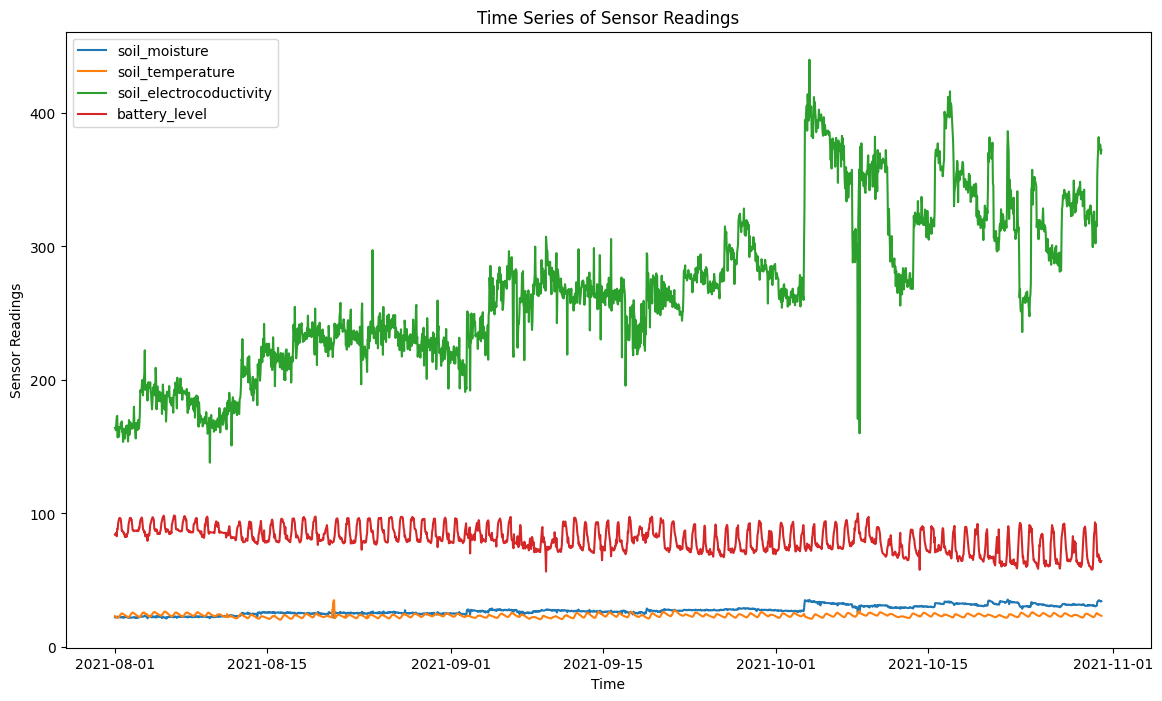

Correlation Matrix:
                               id  soil_moisture  soil_temperature  \
id                       1.000000       0.910422          0.094948   
soil_moisture            0.910422       1.000000         -0.006098   
soil_temperature         0.094948      -0.006098          1.000000   
soil_electrocoductivity  0.855707       0.948843          0.047192   
battery_level           -0.547272      -0.514592          0.125684   

                         soil_electrocoductivity  battery_level  
id                                      0.855707      -0.547272  
soil_moisture                           0.948843      -0.514592  
soil_temperature                        0.047192       0.125684  
soil_electrocoductivity                 1.000000      -0.457923  
battery_level                          -0.457923       1.000000  


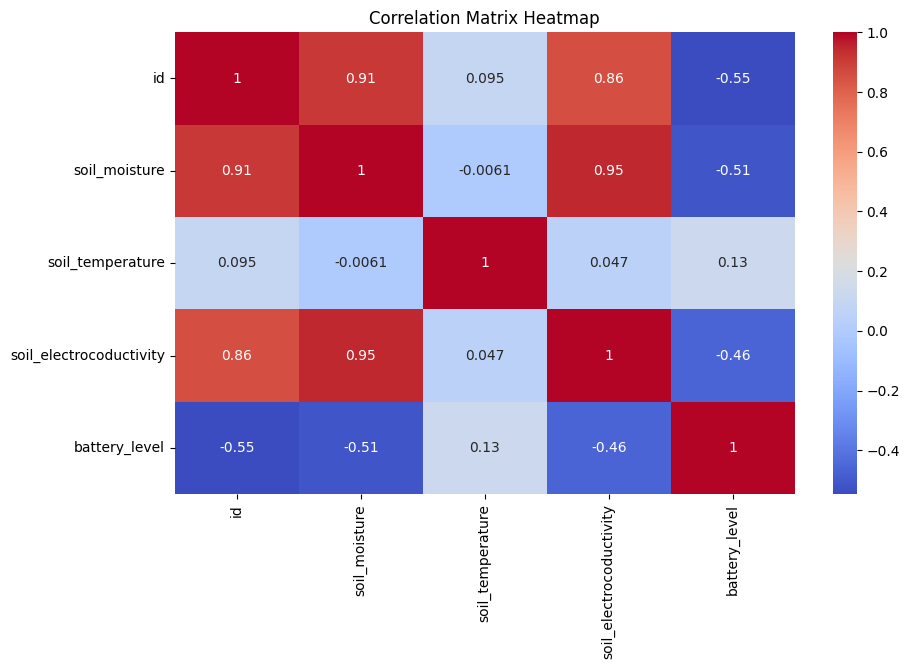

In [38]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime

# Check the index name of the DataFrame
print("Index name in the DataFrame:", df.index.name)

# Ensure the index is 'createdAt'
if df.index.name != 'createdAt':
    raise KeyError("The index is not 'createdAt'.")

# Ensure numeric columns
numeric_columns = ['soil_moisture', 'soil_temperature', 'soil_electrocoductivity', 'battery_level']
df[numeric_columns] = df[numeric_columns].apply(pd.to_numeric, errors='coerce')

# Handle missing values (e.g., fill with the mean of each column)
df[numeric_columns] = df[numeric_columns].fillna(df[numeric_columns].mean())

# Check for non-numeric columns
non_numeric_columns = df.select_dtypes(exclude=['number']).columns
if len(non_numeric_columns) > 0:
    print(f"Non-numeric columns found: {non_numeric_columns}")
    df = df.drop(columns=non_numeric_columns)

# Resample data to hourly frequency and aggregate
df_resampled = df.resample('H').mean()

# Plot time series data
plt.figure(figsize=(14, 8))
for column in numeric_columns:
    plt.plot(df_resampled.index, df_resampled[column], label=column)

plt.xlabel('Time')
plt.ylabel('Sensor Readings')
plt.title('Time Series of Sensor Readings')
plt.legend()
plt.show()

# Statistical analysis: Correlation matrix
correlation_matrix = df_resampled.corr()
print("Correlation Matrix:")
print(correlation_matrix)

# Heatmap of the correlation matrix
plt.figure(figsize=(10, 6))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm')
plt.title('Correlation Matrix Heatmap')
plt.show()

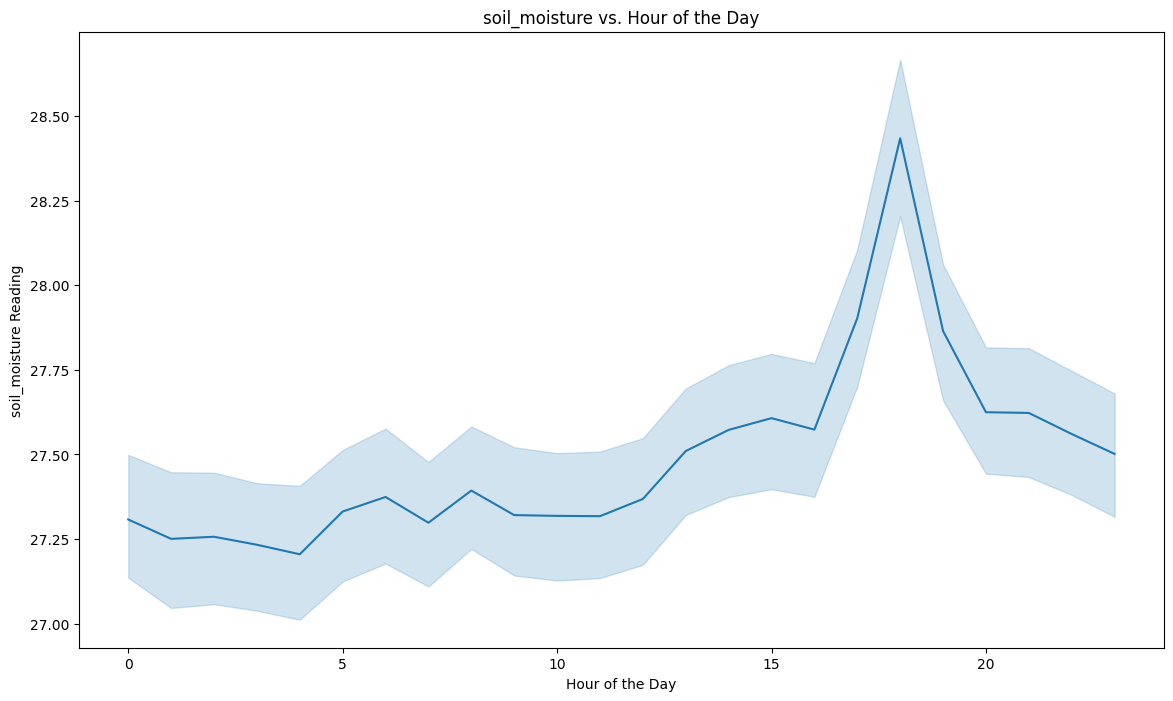

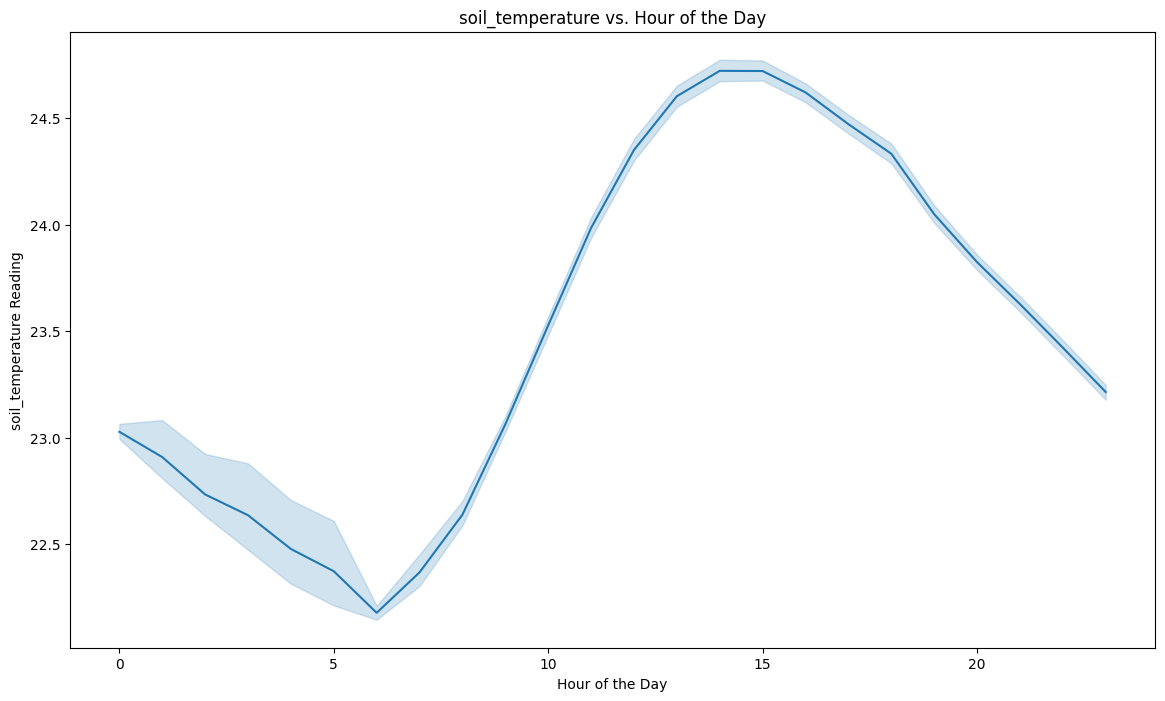

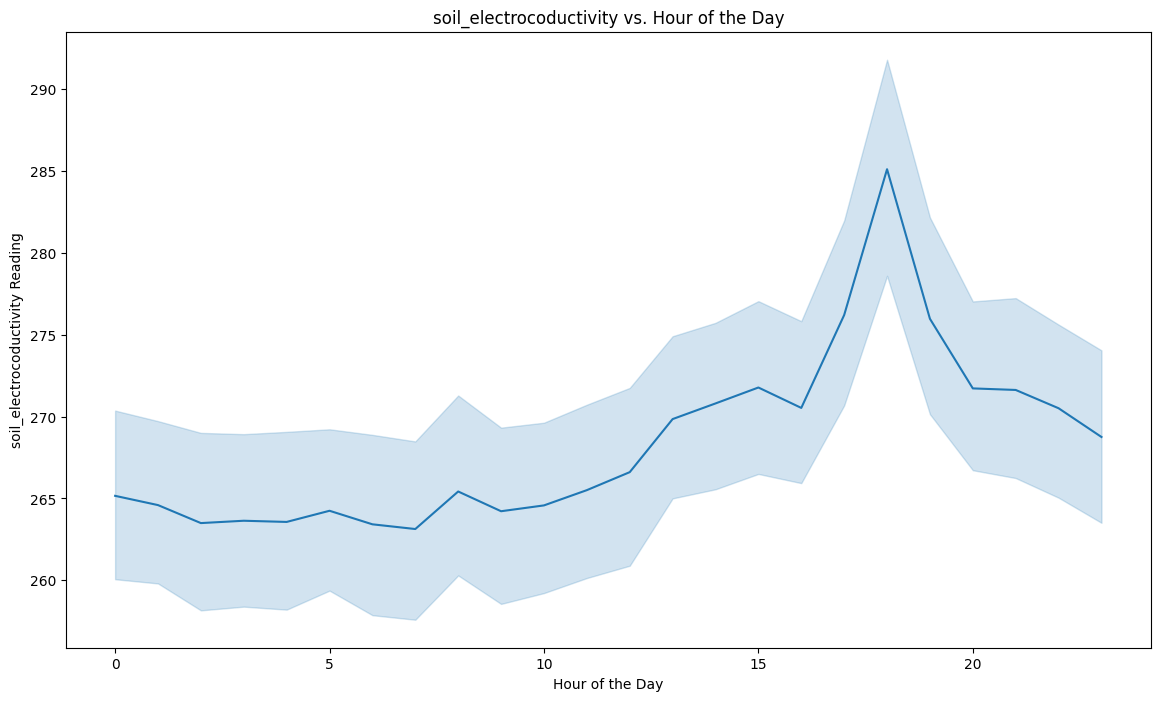

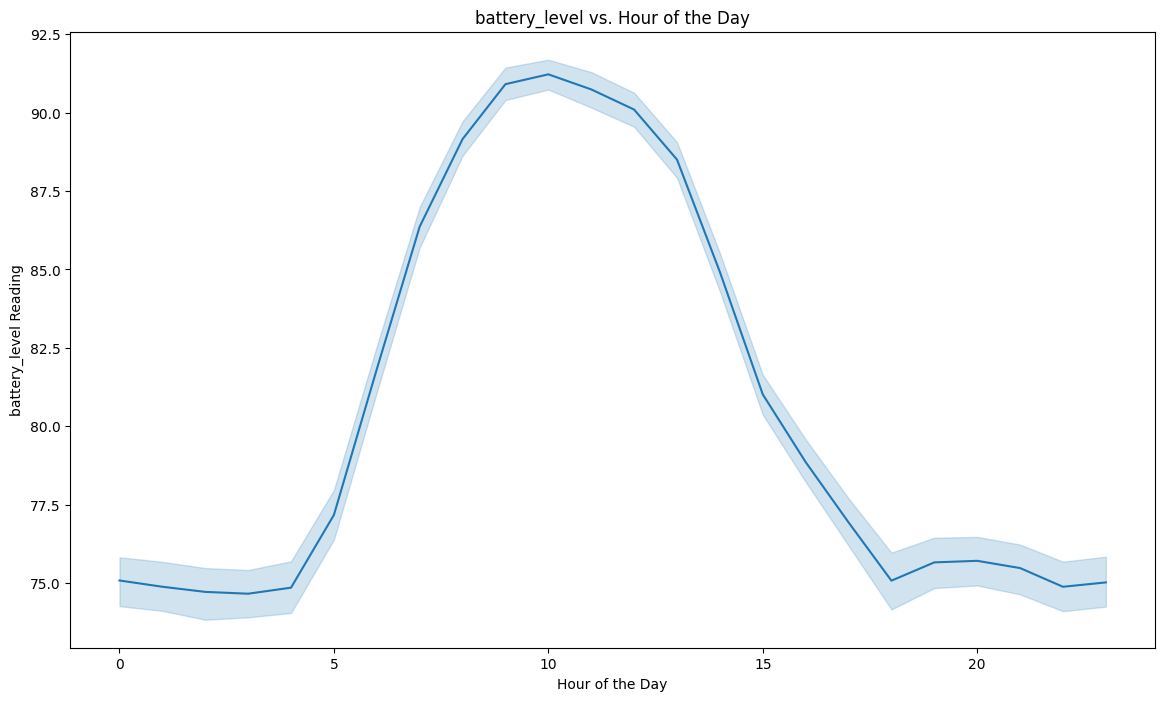

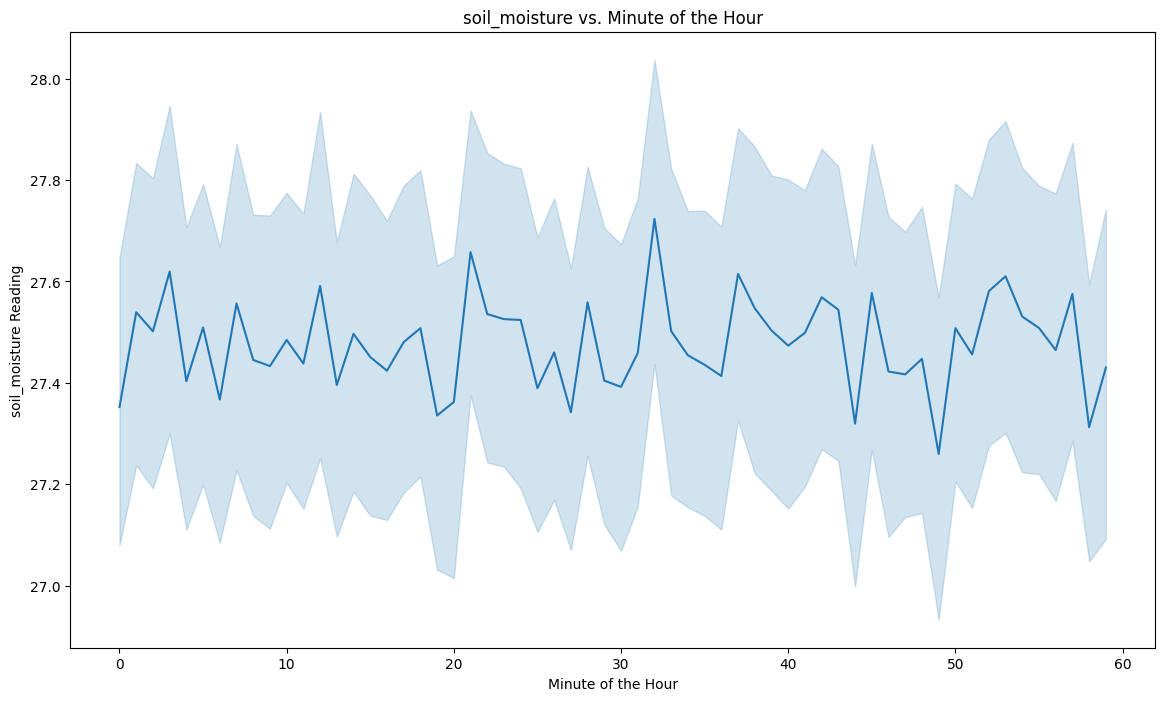

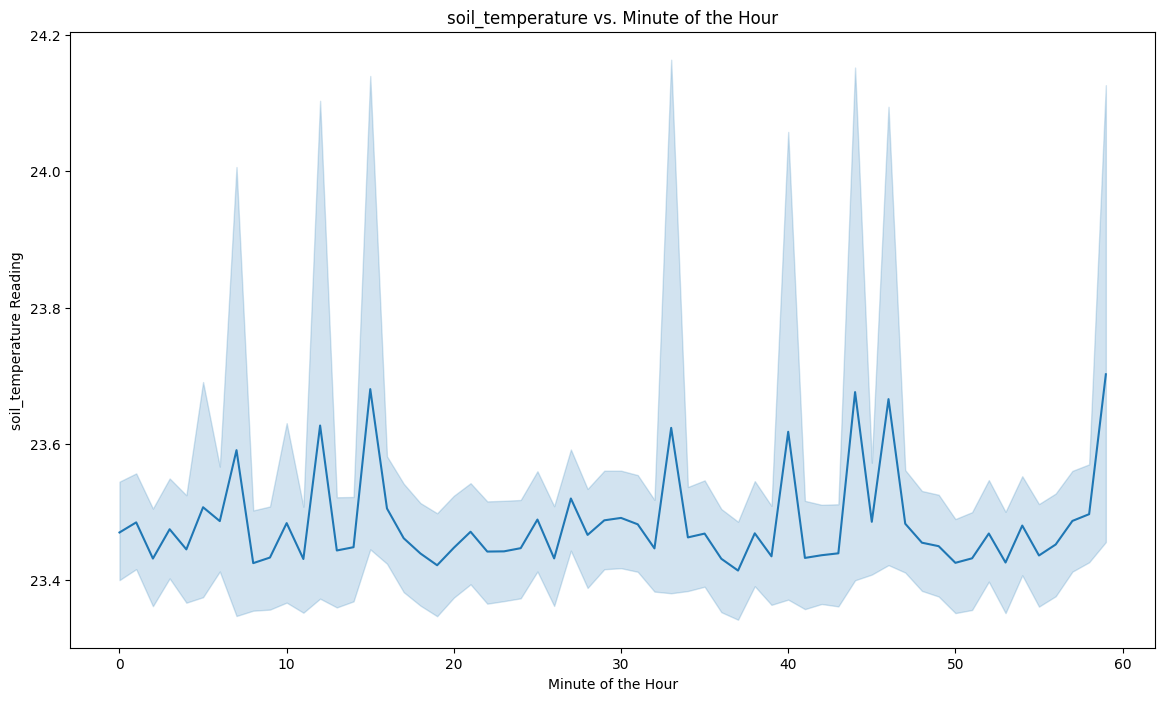

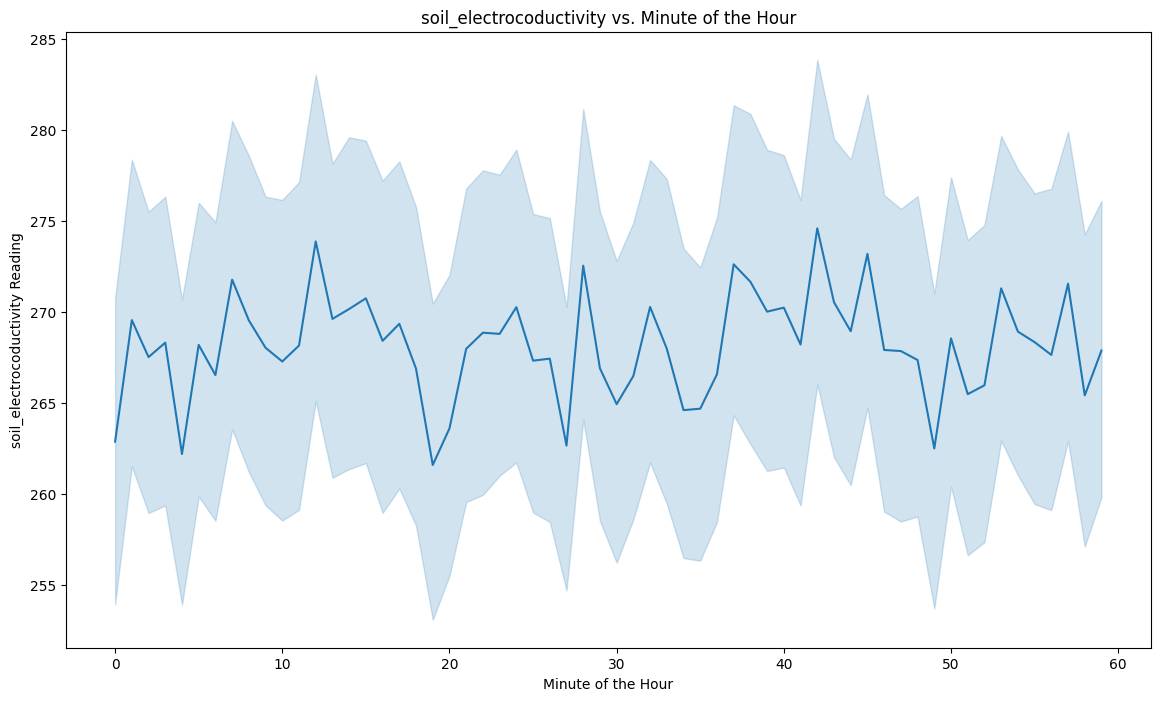

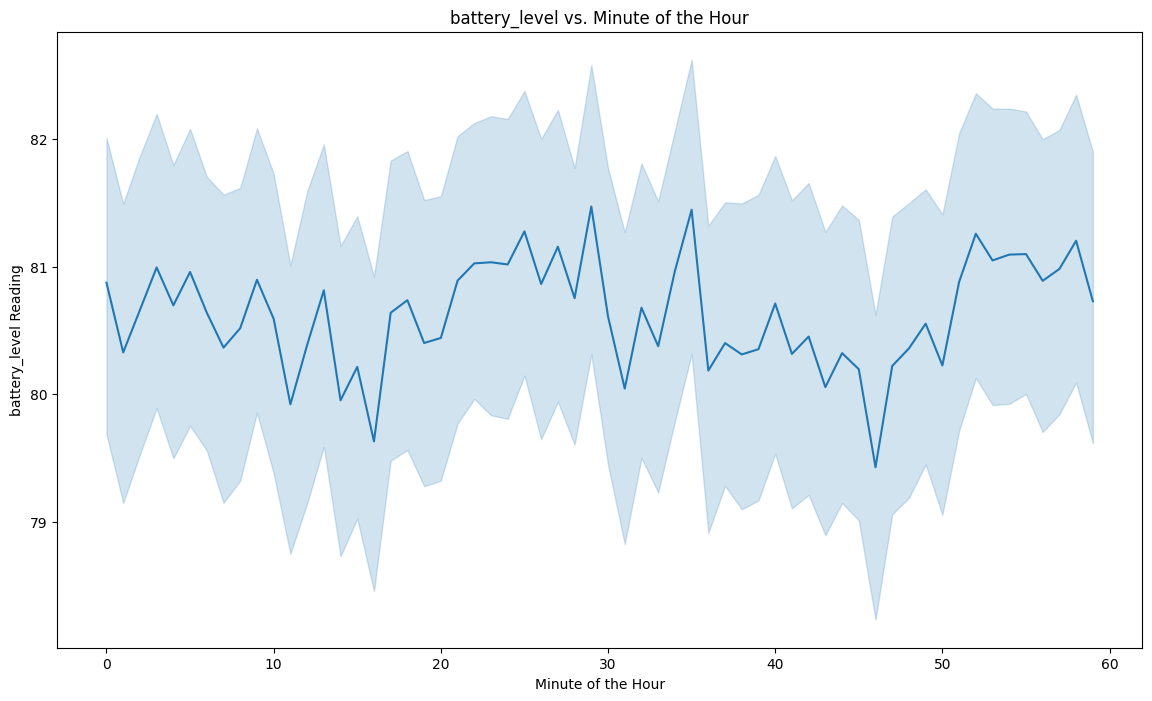

In [40]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Ensure the index is 'createdAt'
if df.index.name != 'createdAt':
    raise KeyError("The index is not 'createdAt'.")

# Extract hour and minute components
df['hour'] = df.index.hour
df['minute'] = df.index.minute

# Ensure numeric columns
numeric_columns = ['soil_moisture', 'soil_temperature', 'soil_electrocoductivity', 'battery_level']
df[numeric_columns] = df[numeric_columns].apply(pd.to_numeric, errors='coerce')

# Handle missing values (e.g., fill with the mean of each column)
df[numeric_columns] = df[numeric_columns].fillna(df[numeric_columns].mean())

# Plot sensor readings against hour of the day
for column in numeric_columns:
    plt.figure(figsize=(14, 8))
    sns.lineplot(x='hour', y=column, data=df)
    plt.xlabel('Hour of the Day')
    plt.ylabel(f'{column} Reading')
    plt.title(f'{column} vs. Hour of the Day')
    plt.show()

# Plot sensor readings against minute of the hour
for column in numeric_columns:
    plt.figure(figsize=(14, 8))
    sns.lineplot(x='minute', y=column, data=df)
    plt.xlabel('Minute of the Hour')
    plt.ylabel(f'{column} Reading')
    plt.title(f'{column} vs. Minute of the Hour')
    plt.show()

In [6]:
# Initialize and train
simulator = EnvironmentalSensorSimulator()
simulator.fit(df)

# Generate new data
start_time = datetime.now()
simulated_data = simulator.generate_values(
    start_datetime=start_time,
    n_points=24,
    interval_minutes=60
)

# Display results
print("\nSimulated Data Sample:")
print(simulated_data.head())


R² Score for A201 - soil_moisture: 0.9992, MSE: 0.0009
R² Score for A201 - soil_temperature: 0.9993, MSE: 0.0007
R² Score for A201 - soil_electrocoductivity: 0.9991, MSE: 0.0010
R² Score for A201 - battery_level: 0.9999, MSE: 0.0001
R² Score for A202 - soil_moisture: 0.9997, MSE: 0.0004
R² Score for A202 - soil_temperature: 0.9994, MSE: 0.0005
R² Score for A202 - soil_electrocoductivity: 0.9997, MSE: 0.0004
R² Score for A202 - battery_level: 0.9999, MSE: 0.0001
R² Score for A203 - soil_moisture: 0.9994, MSE: 0.0006
R² Score for A203 - soil_temperature: 0.9990, MSE: 0.0009
R² Score for A203 - soil_electrocoductivity: 0.9989, MSE: 0.0011
R² Score for A203 - battery_level: 1.0000, MSE: 0.0000
R² Score for C911 - soil_moisture: 0.9996, MSE: 0.0004
R² Score for C911 - soil_temperature: 0.9994, MSE: 0.0005
R² Score for C911 - soil_electrocoductivity: 0.9996, MSE: 0.0003
R² Score for C911 - battery_level: 0.9998, MSE: 0.0002
R² Score for C906 - soil_moisture: 0.9999, MSE: 0.0001
R² Score for 

In [7]:
from joblib import dump
dump(simulator.models, 'thingsboard-control/models.joblib')
dump(simulator.scalers_X, 'thingsboard-control/scalers_X.joblib')
dump(simulator.scalers_y, 'thingsboard-control/scalers_y.joblib')

['thingsboard-control/scalers_y.joblib']

/home/claude/.local/lib/python3.10/site-packages/IPython/core/pylabtools.py:170: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


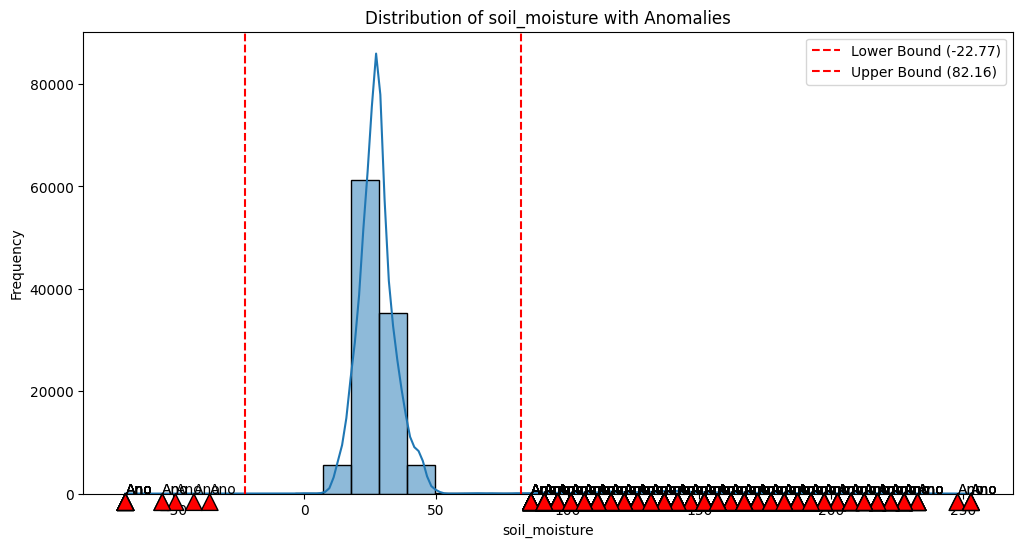

In [21]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# # Read the data
# data_path = "../Data/"
# # Read all csv files in the data folder and concatenate them into a single DataFrame
# df = pd.concat(
#     [pd.read_csv(data_path + f) for f in os.listdir(data_path) if f.endswith('.csv')],
#     ignore_index=True
# )

# Ensure the relevant columns are of type float64
df['soil_moisture'] = df['soil_moisture'].astype('float64')
df['soil_temperature'] = df['soil_temperature'].astype('float64')
df['soil_electrocoductivity'] = df['soil_electrocoductivity'].astype('float64')
df['battery_level'] = df['battery_level'].astype('float64')

def plot_data_distribution(df, parameter, threshold=3):
    plt.figure(figsize=(12, 6))
    
    # Plot the distribution
    sns.histplot(df[parameter], kde=True, bins=30)
    
    # Calculate mean and standard deviation
    mean = df[parameter].mean()
    std = df[parameter].std()
    
    # Define anomaly thresholds
    lower_bound = mean - threshold * std
    upper_bound = mean + threshold * std
    
    # Highlight anomalies
    anomalies = df[(df[parameter] < lower_bound) | (df[parameter] > upper_bound)]
    
    # Plot anomaly thresholds
    plt.axvline(lower_bound, color='r', linestyle='--', label=f'Lower Bound ({lower_bound:.2f})')
    plt.axvline(upper_bound, color='r', linestyle='--', label=f'Upper Bound ({upper_bound:.2f})')
    
    # Annotate anomalies
    for index, row in anomalies.iterrows():
        plt.annotate('Ano', xy=(row[parameter], 0), xytext=(row[parameter], 5),
                     arrowprops=dict(facecolor='red', shrink=0.05))
    
    plt.title(f'Distribution of {parameter} with Anomalies')
    plt.xlabel(parameter)
    plt.ylabel('Frequency')
    plt.legend()
    plt.show()

# Example usage
# Introduce some anomalies
df.loc[::50, 'soil_moisture'] = df['soil_moisture'] * 1.5
df.loc[::50, 'soil_temperature'] = df['soil_temperature'] * 1.5

# Plot distribution and annotate anomalies for 'soil_moisture'
plot_data_distribution(df, 'soil_moisture')

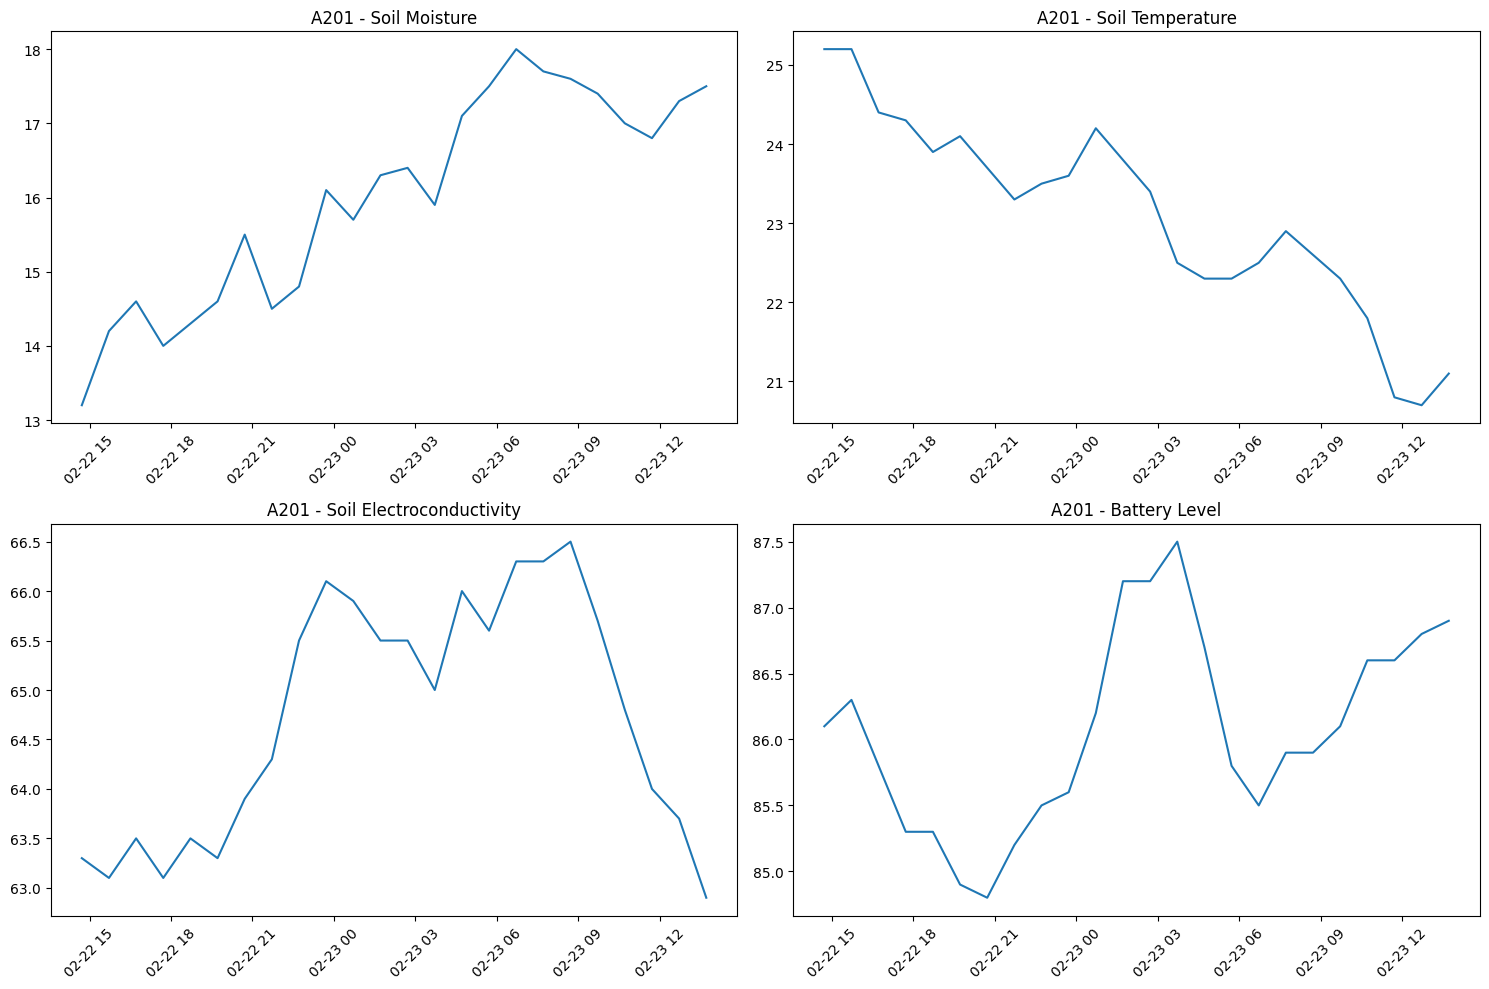

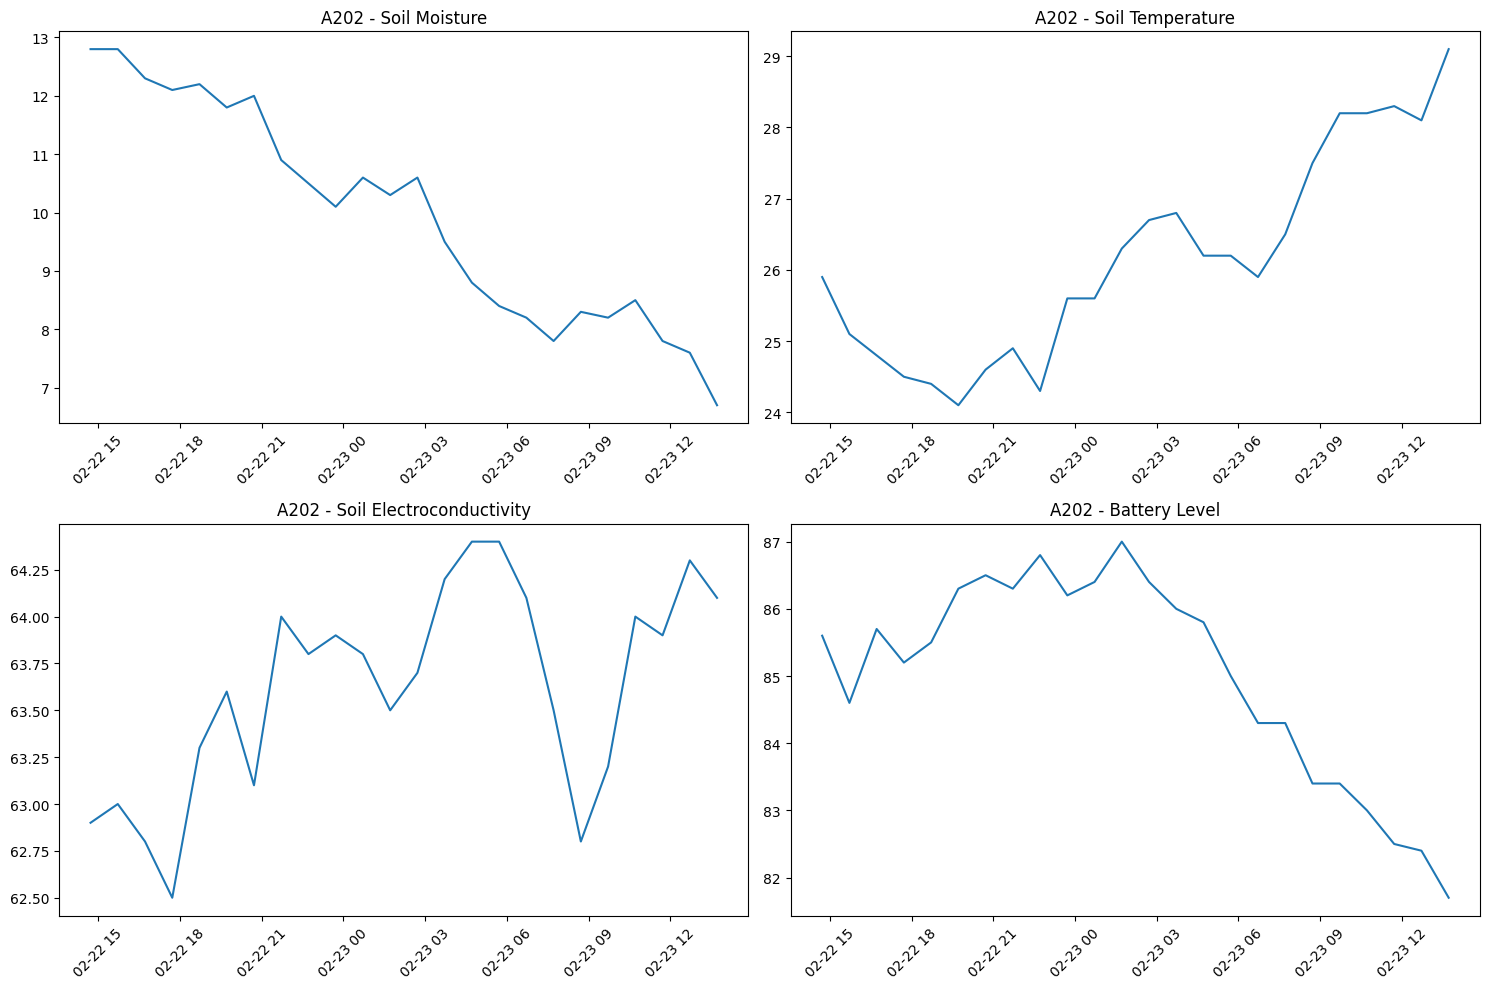

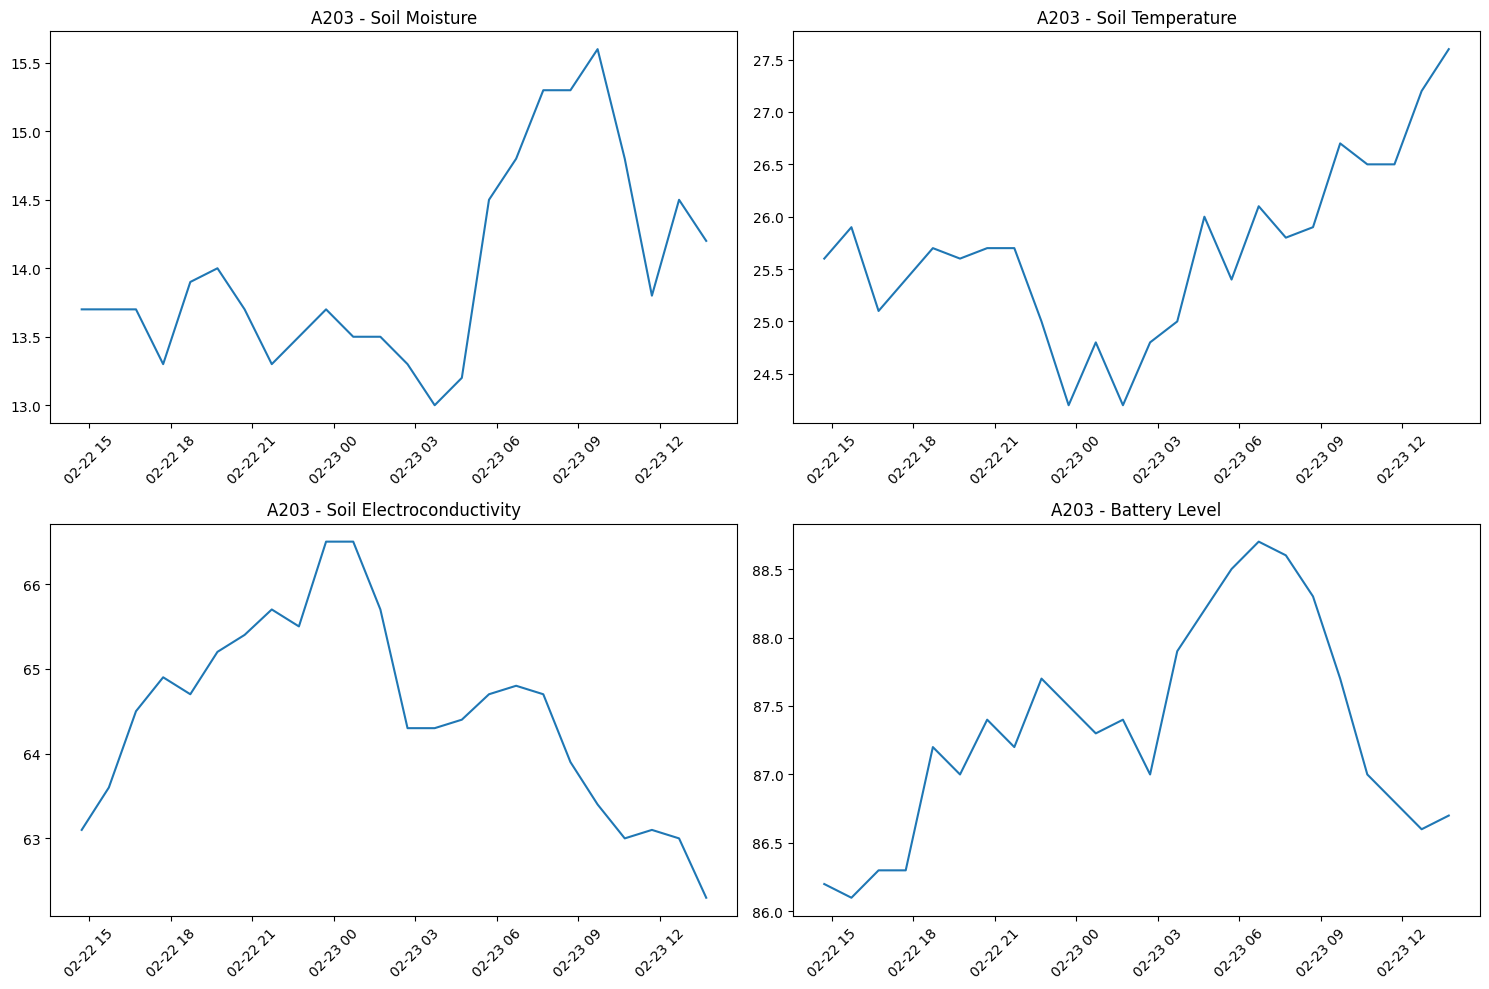

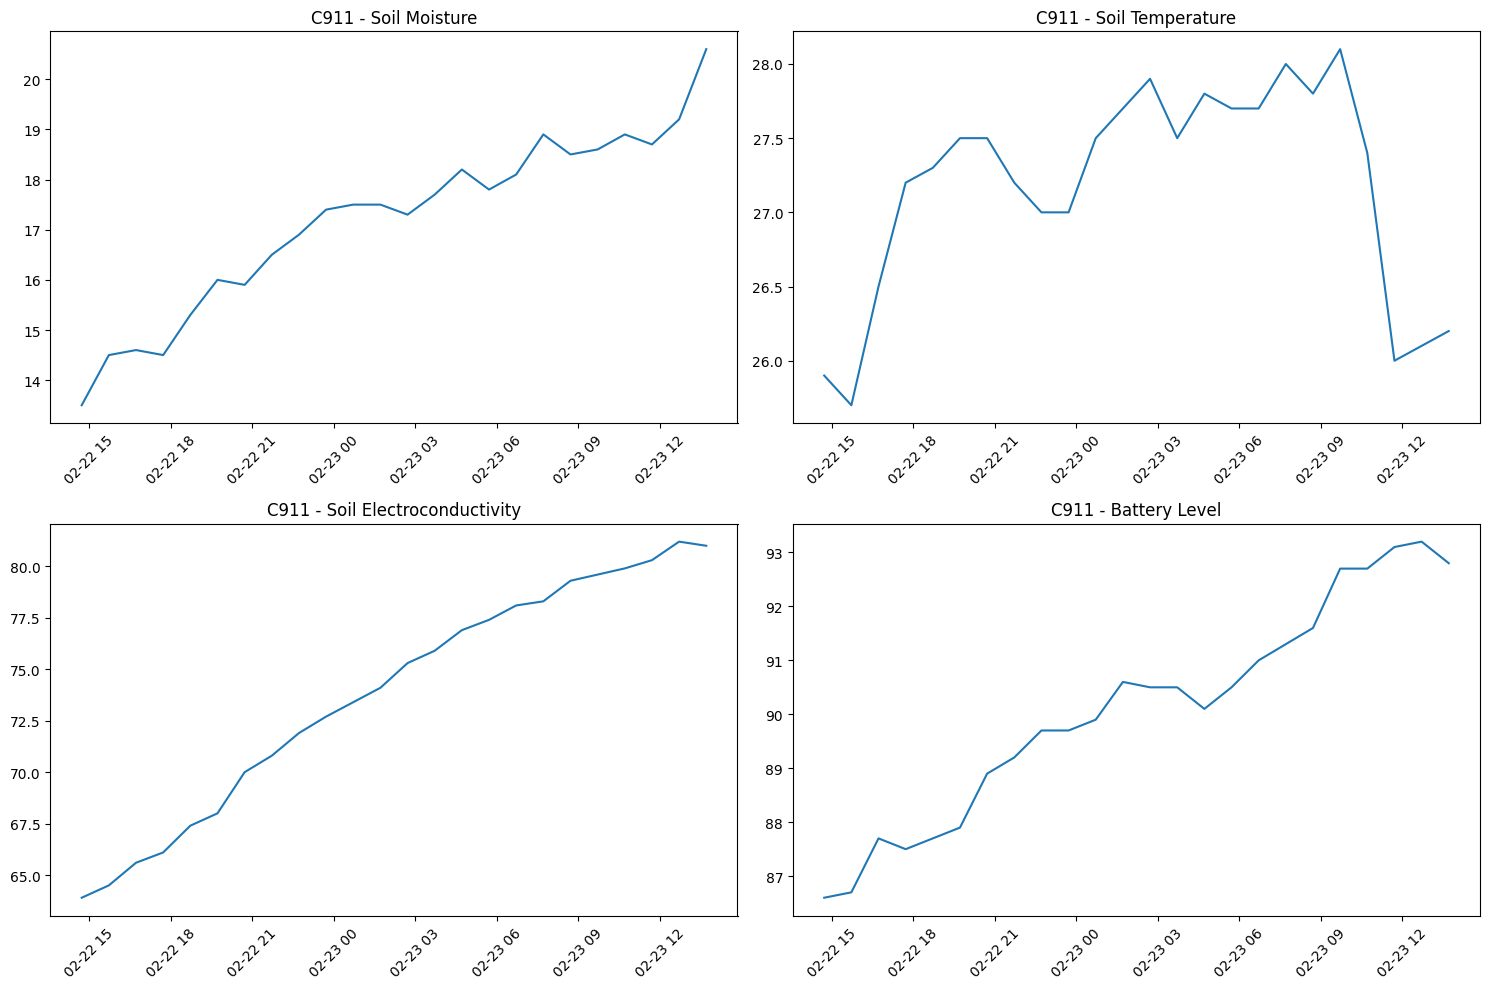

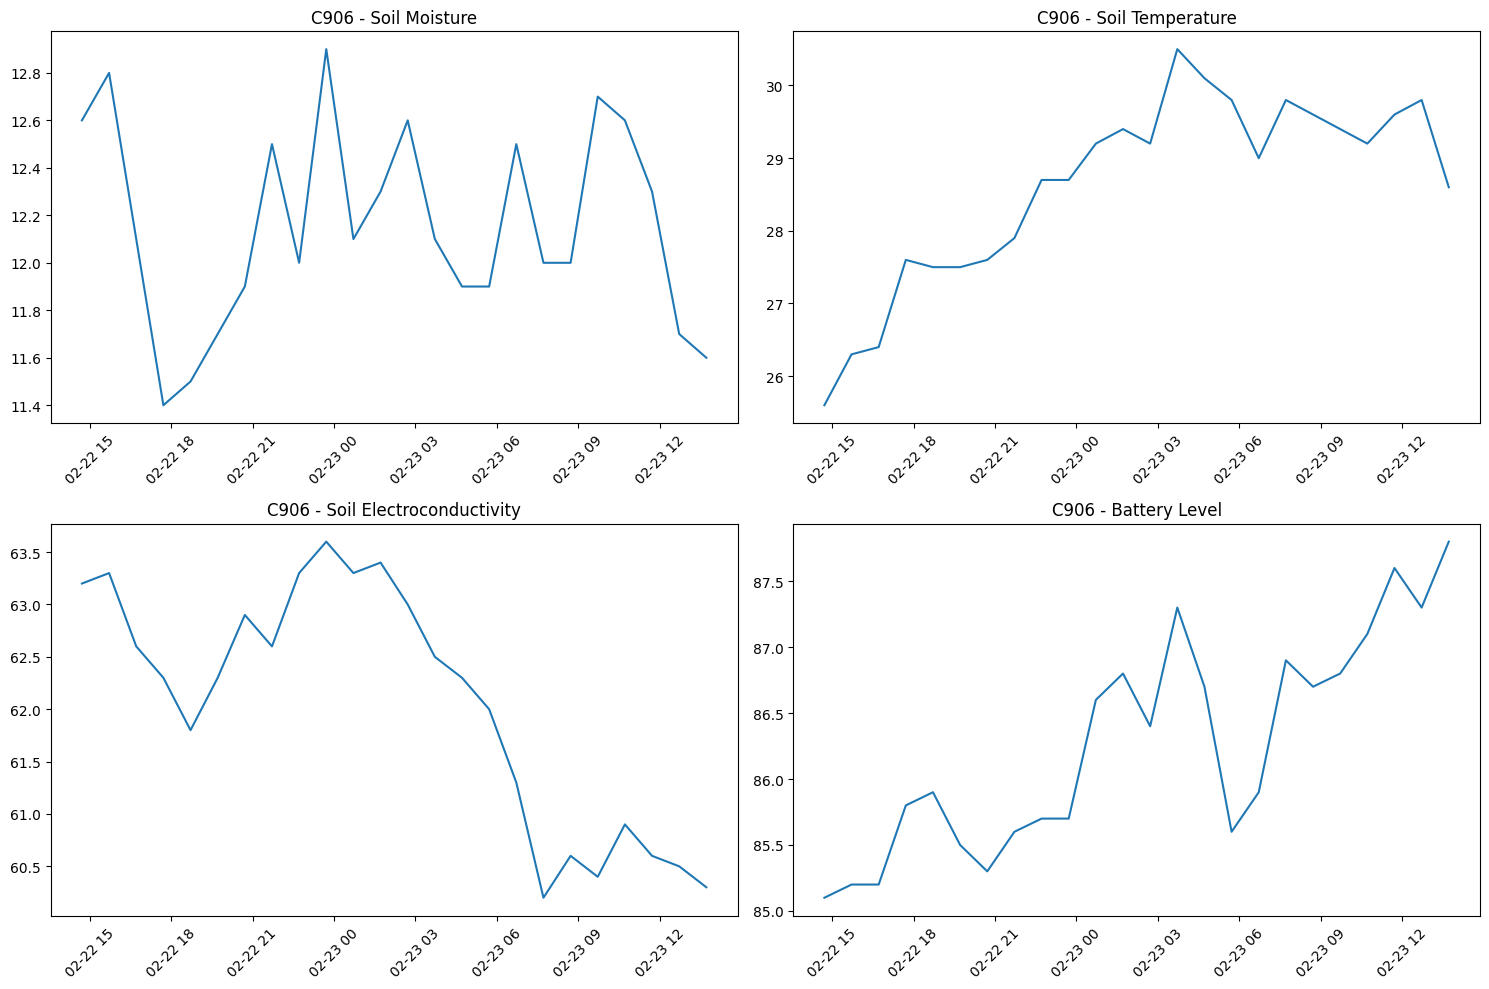

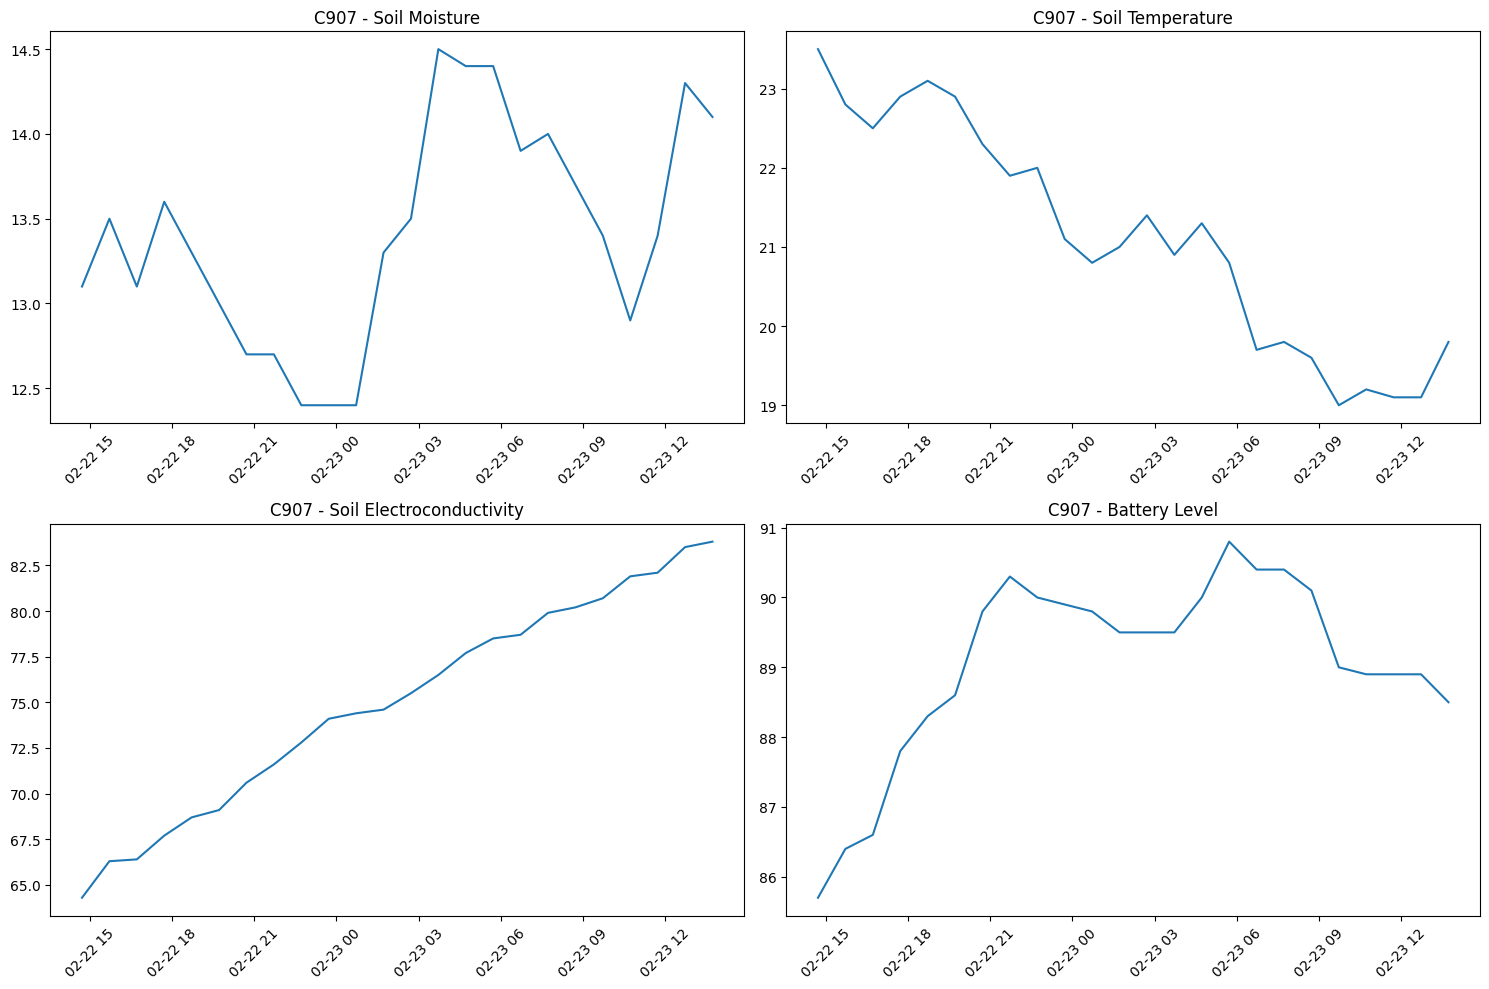

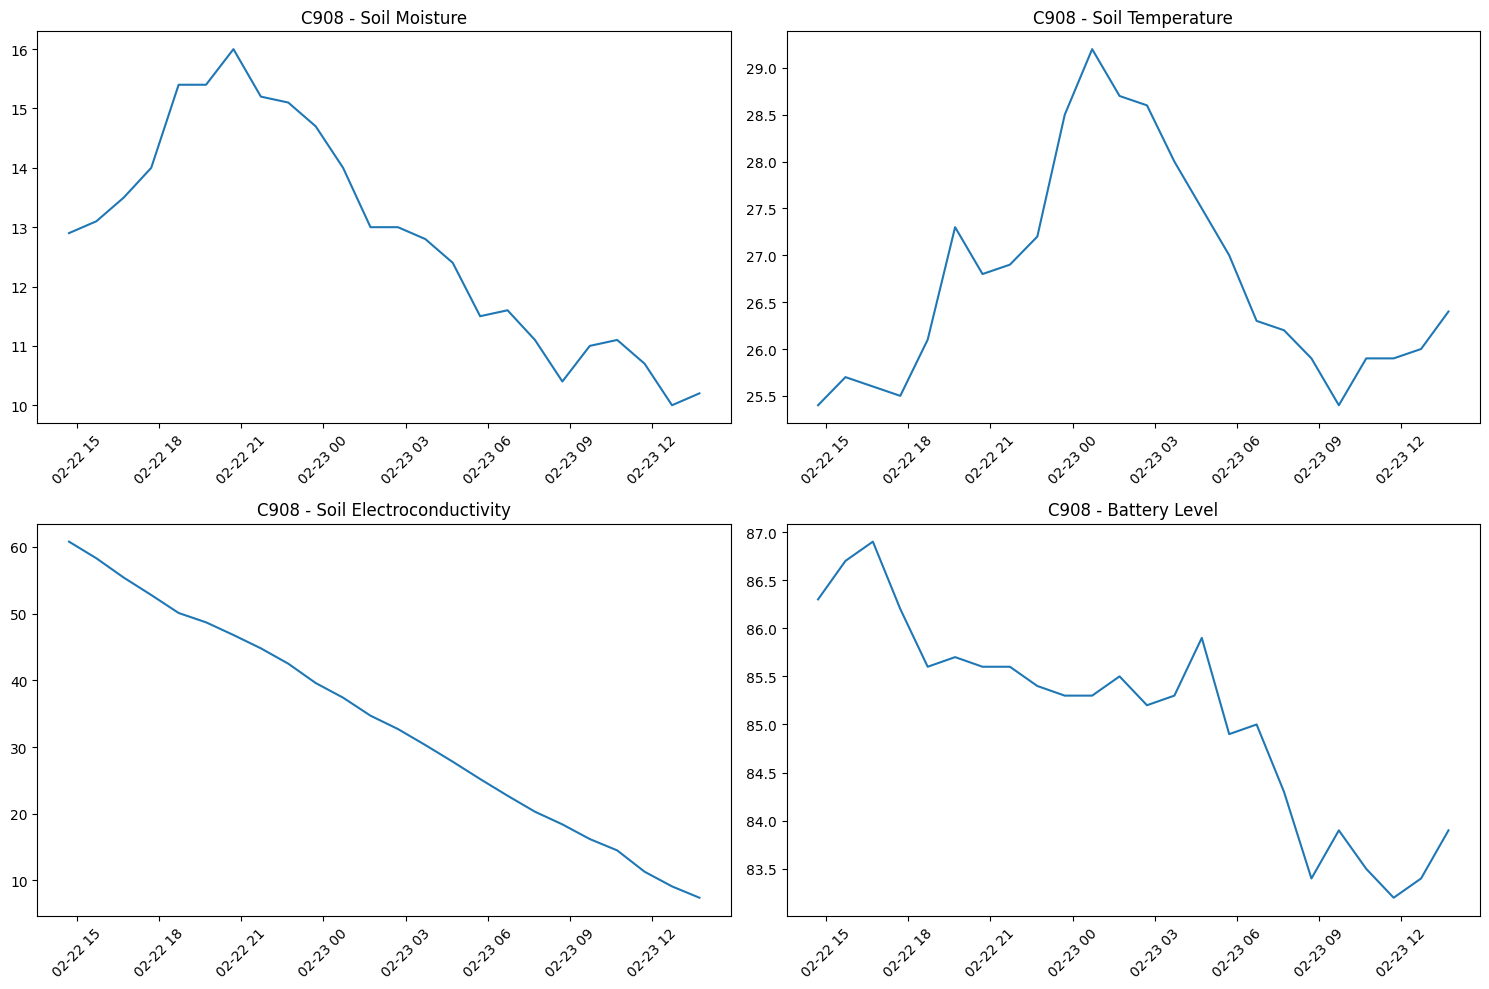

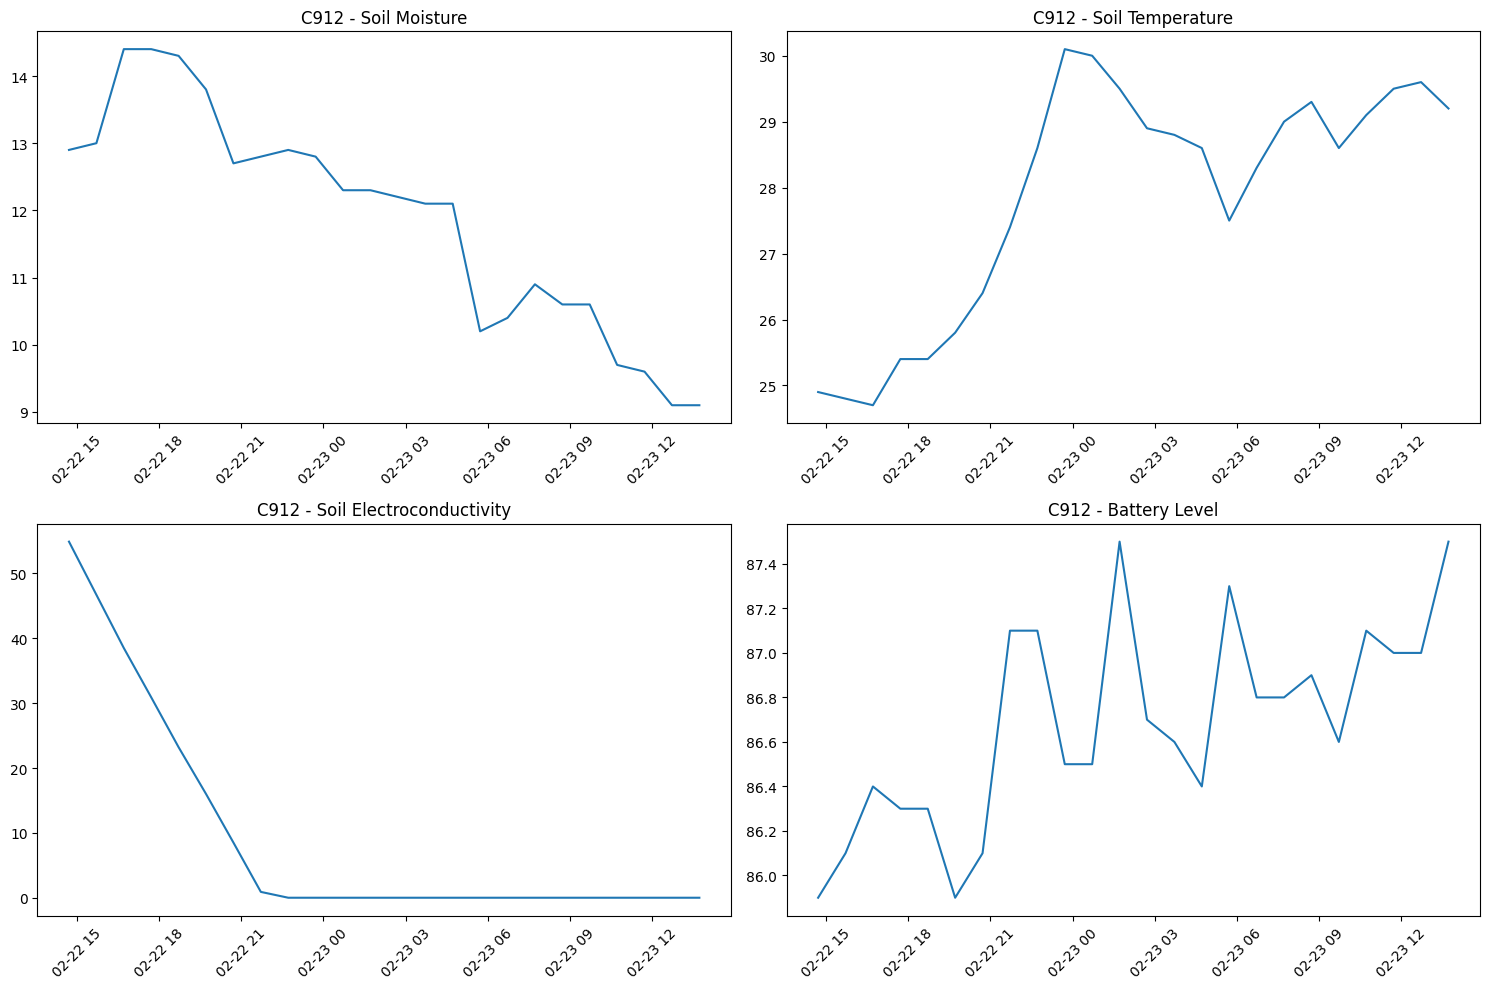

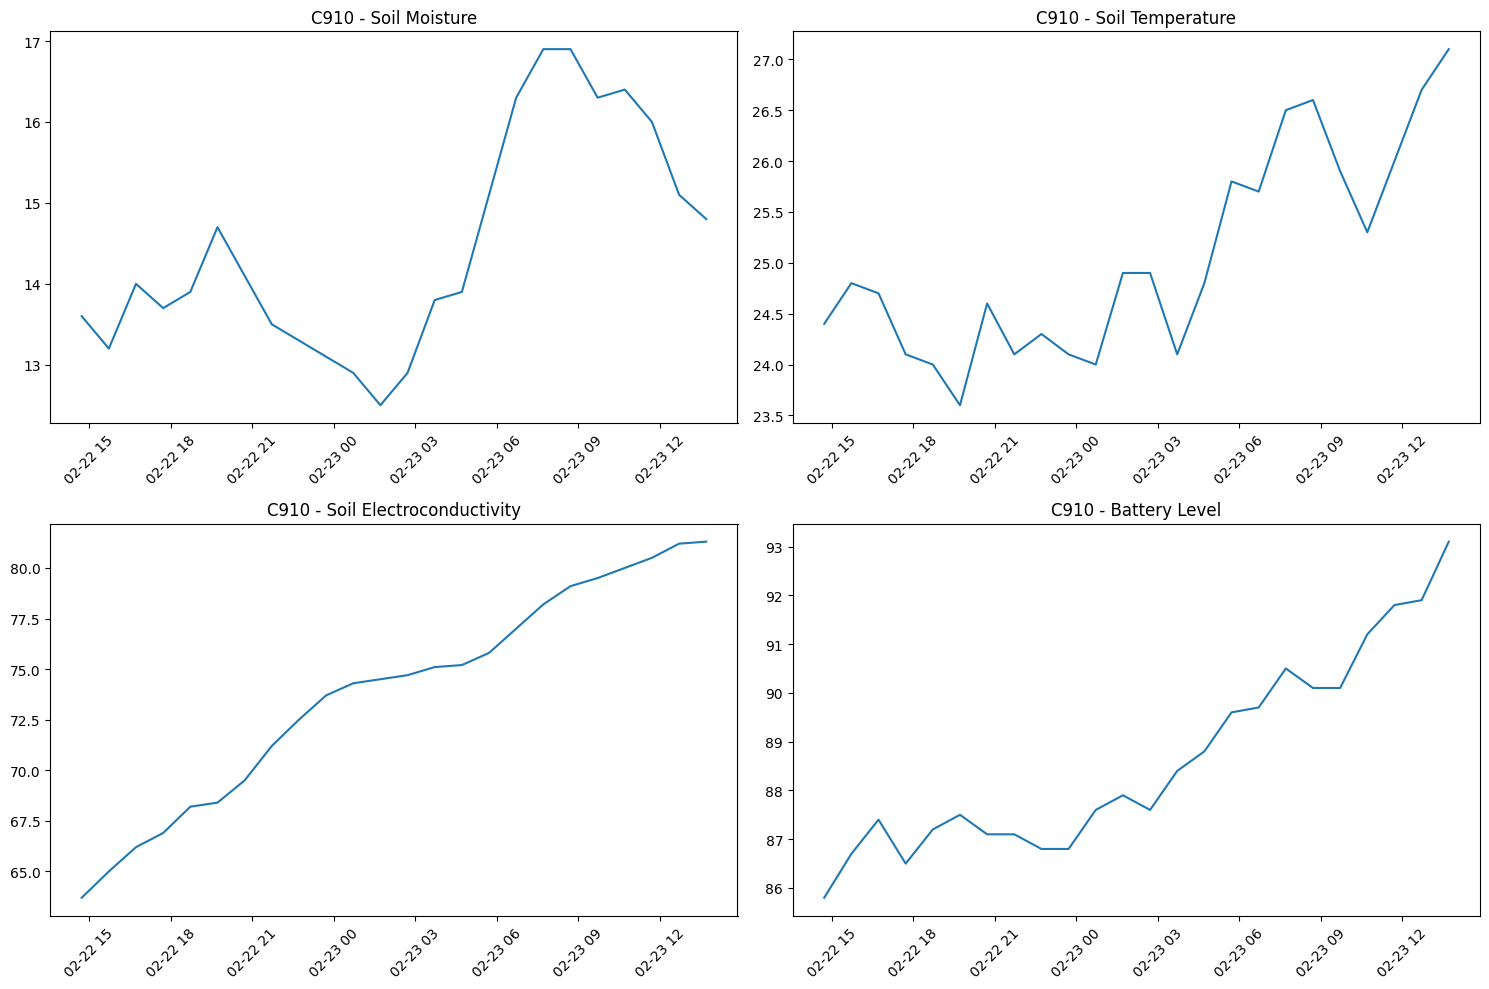

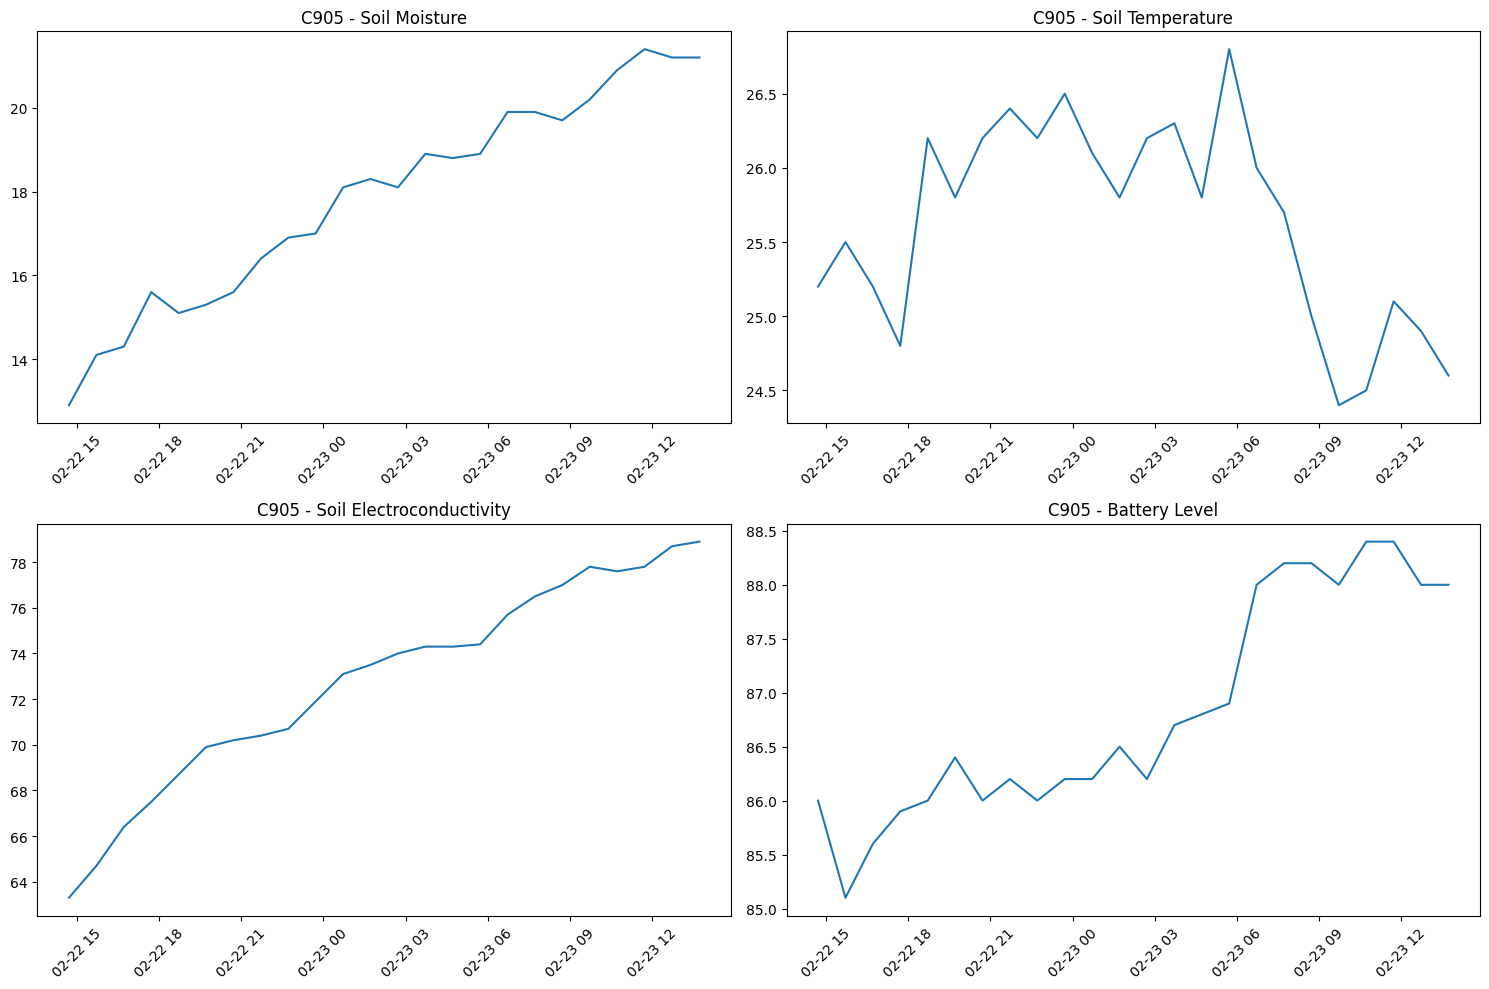

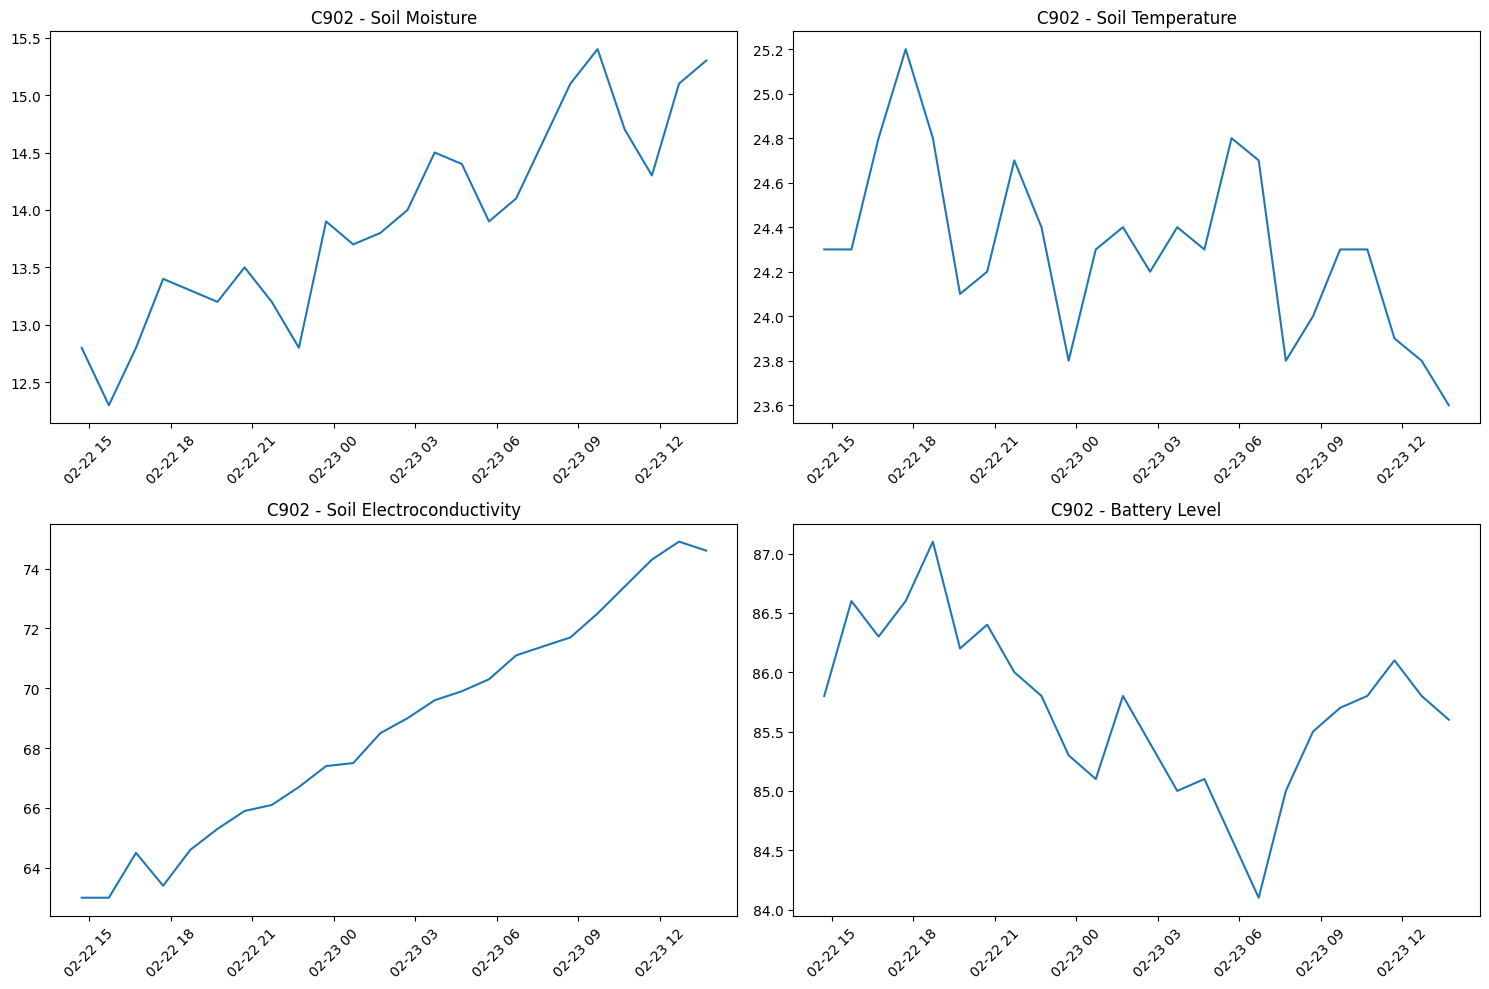

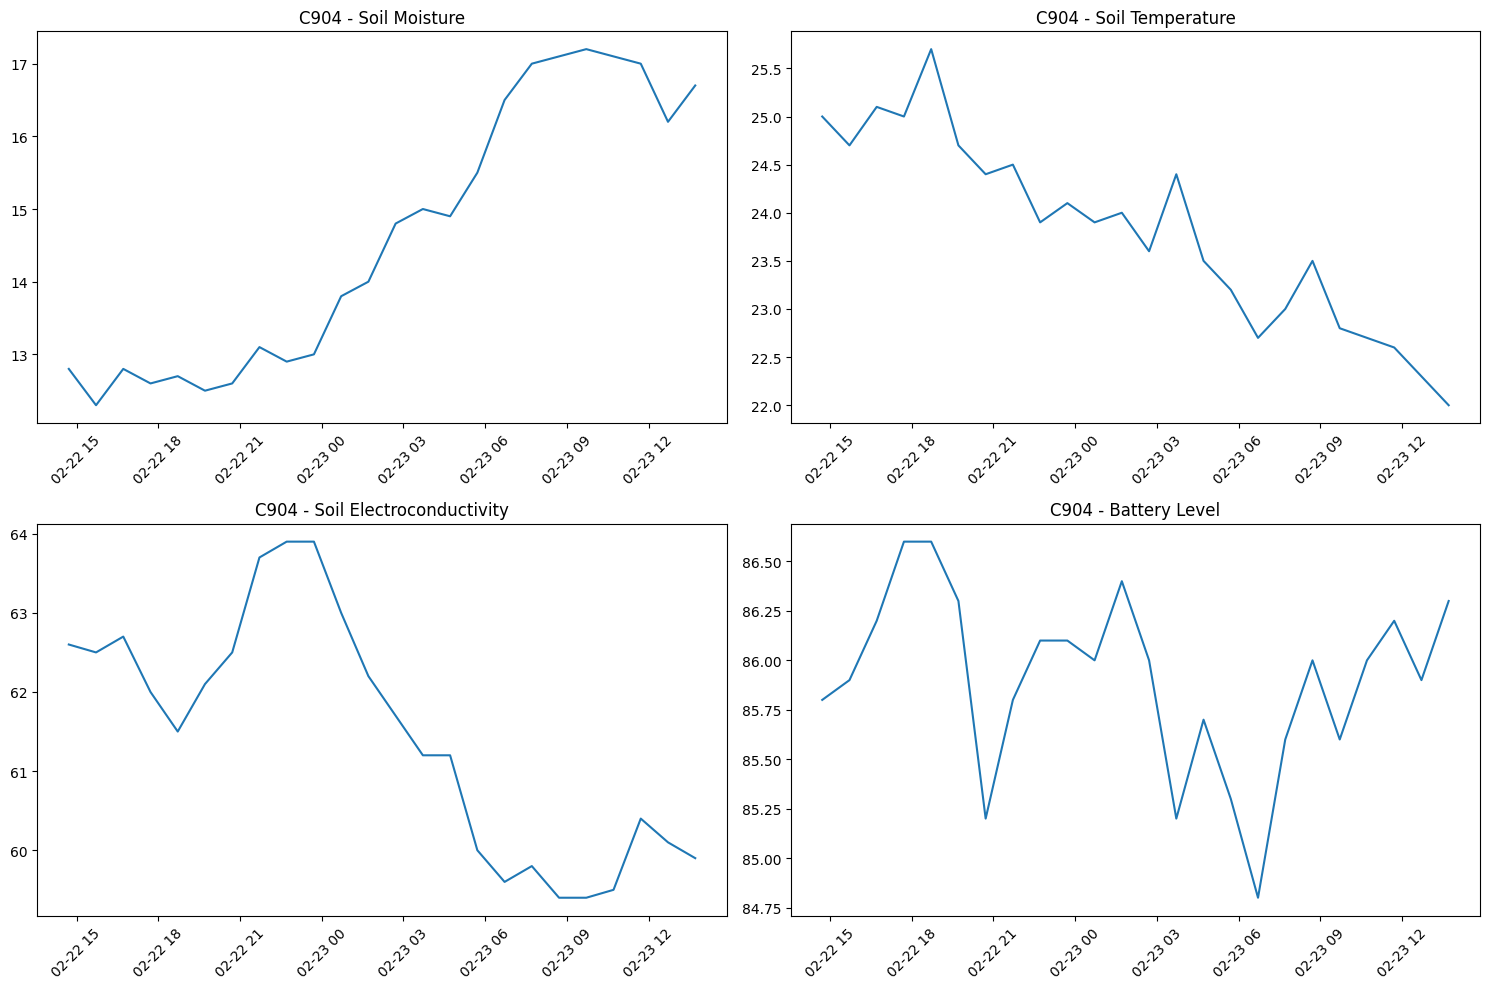

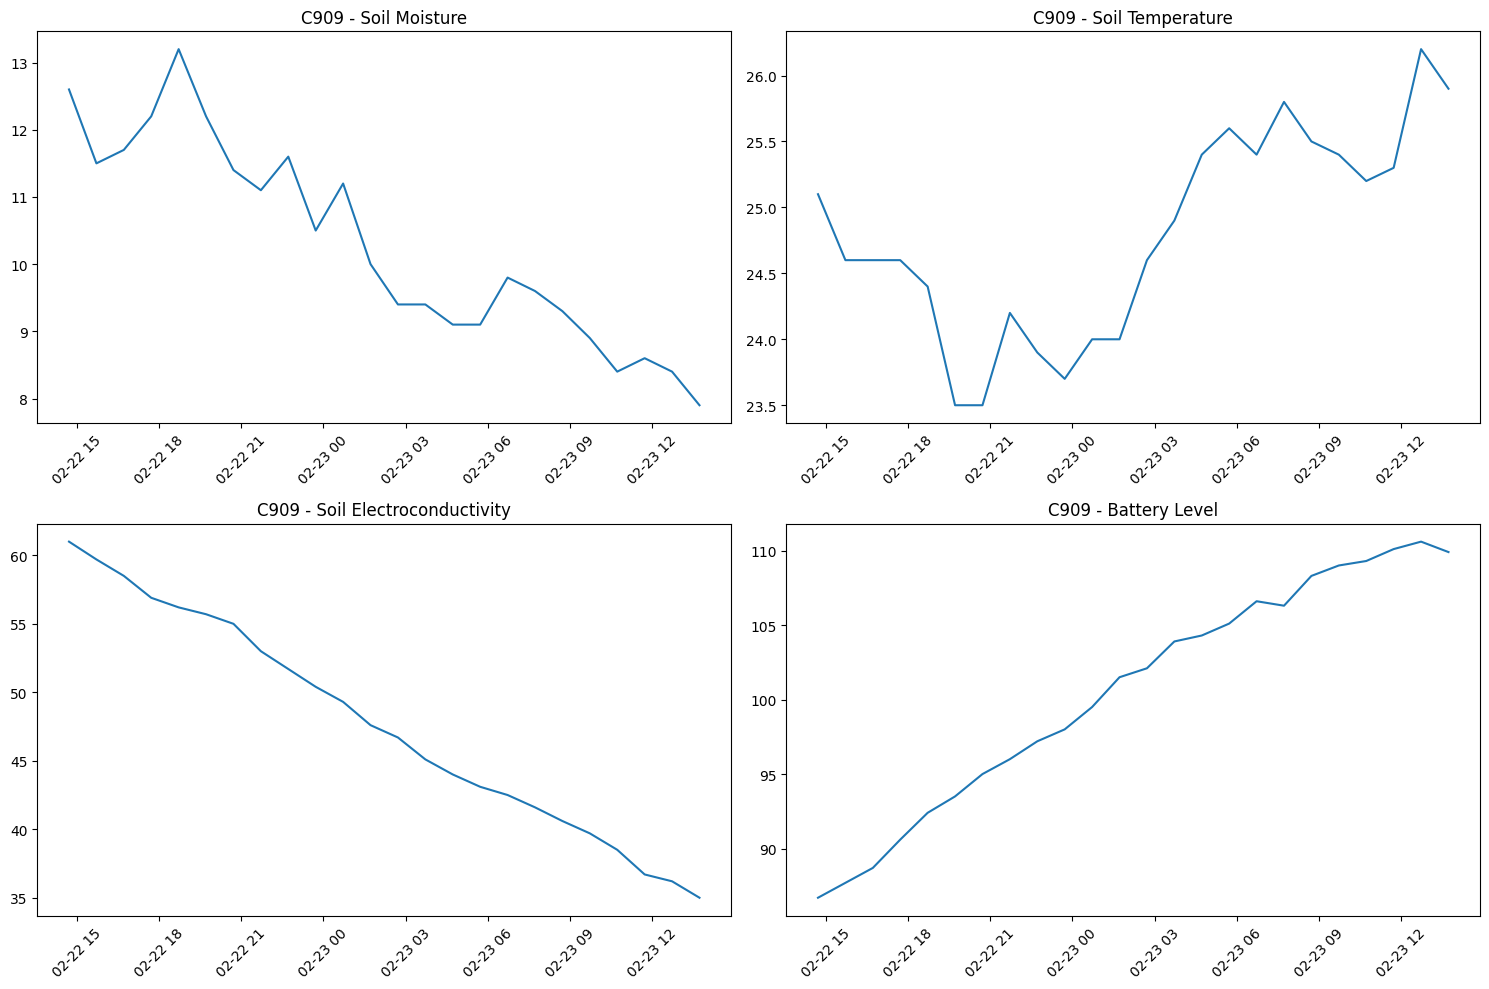

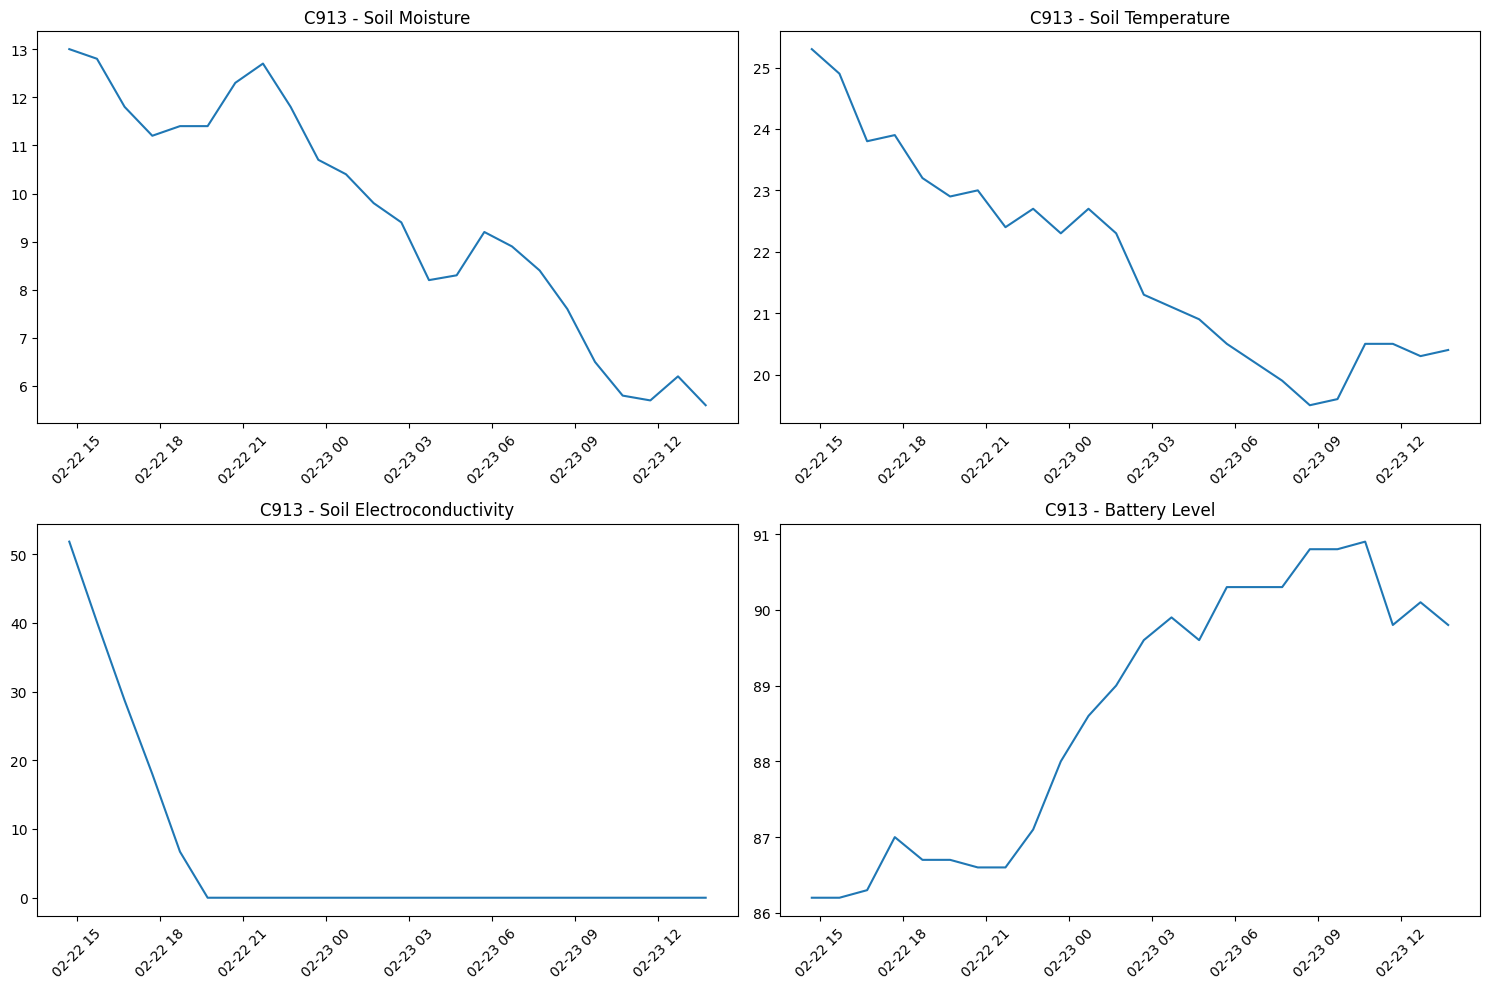

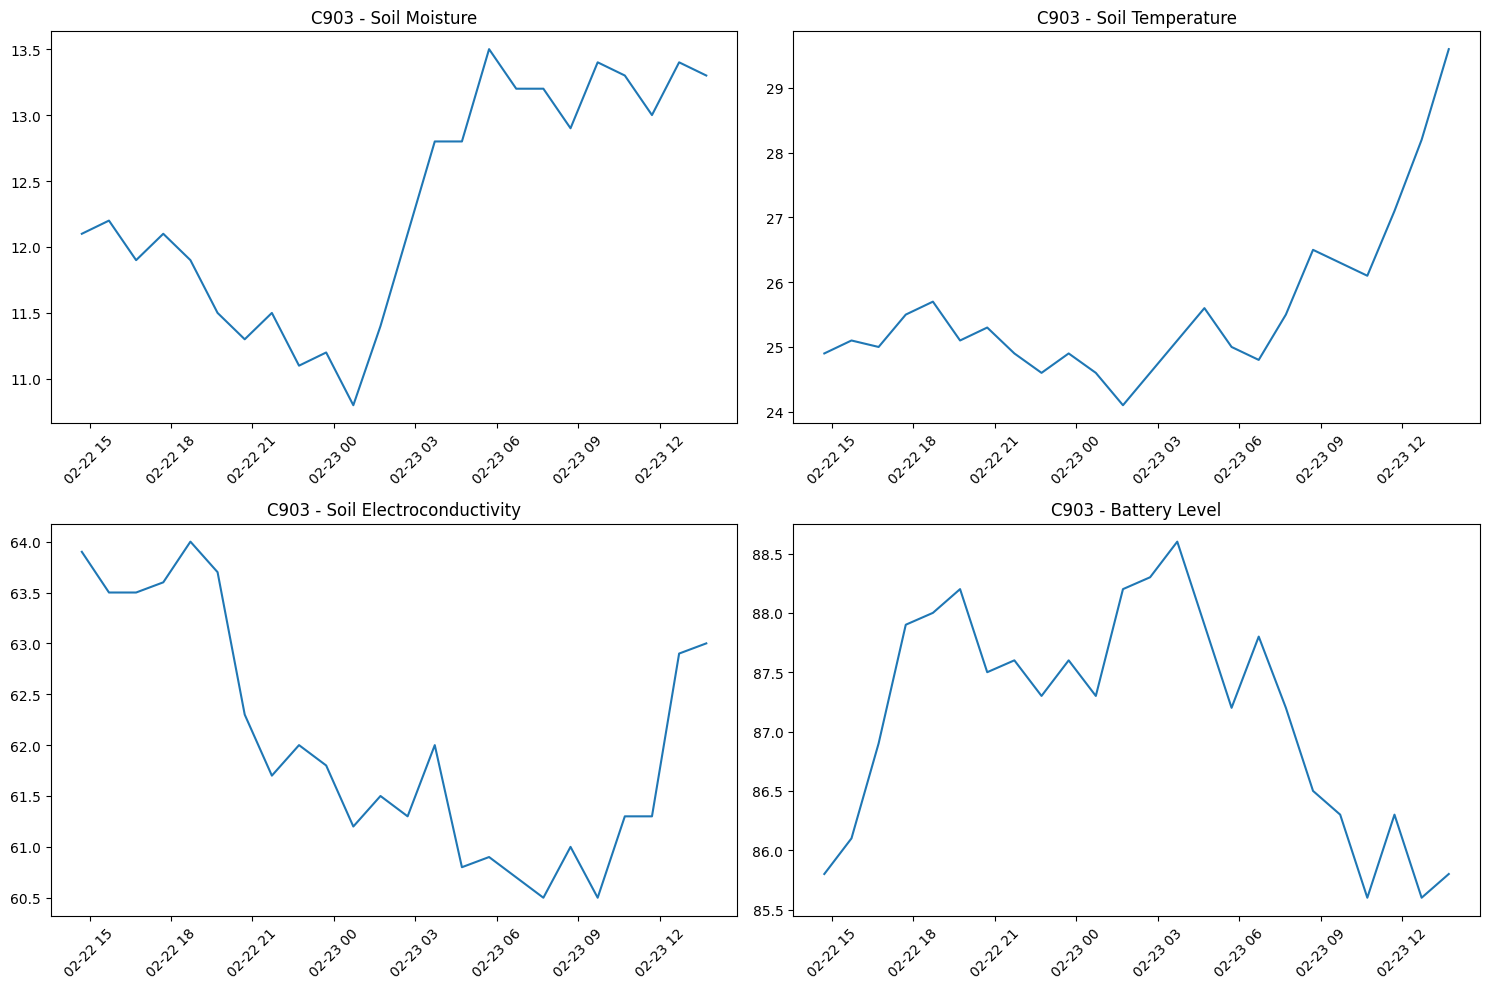

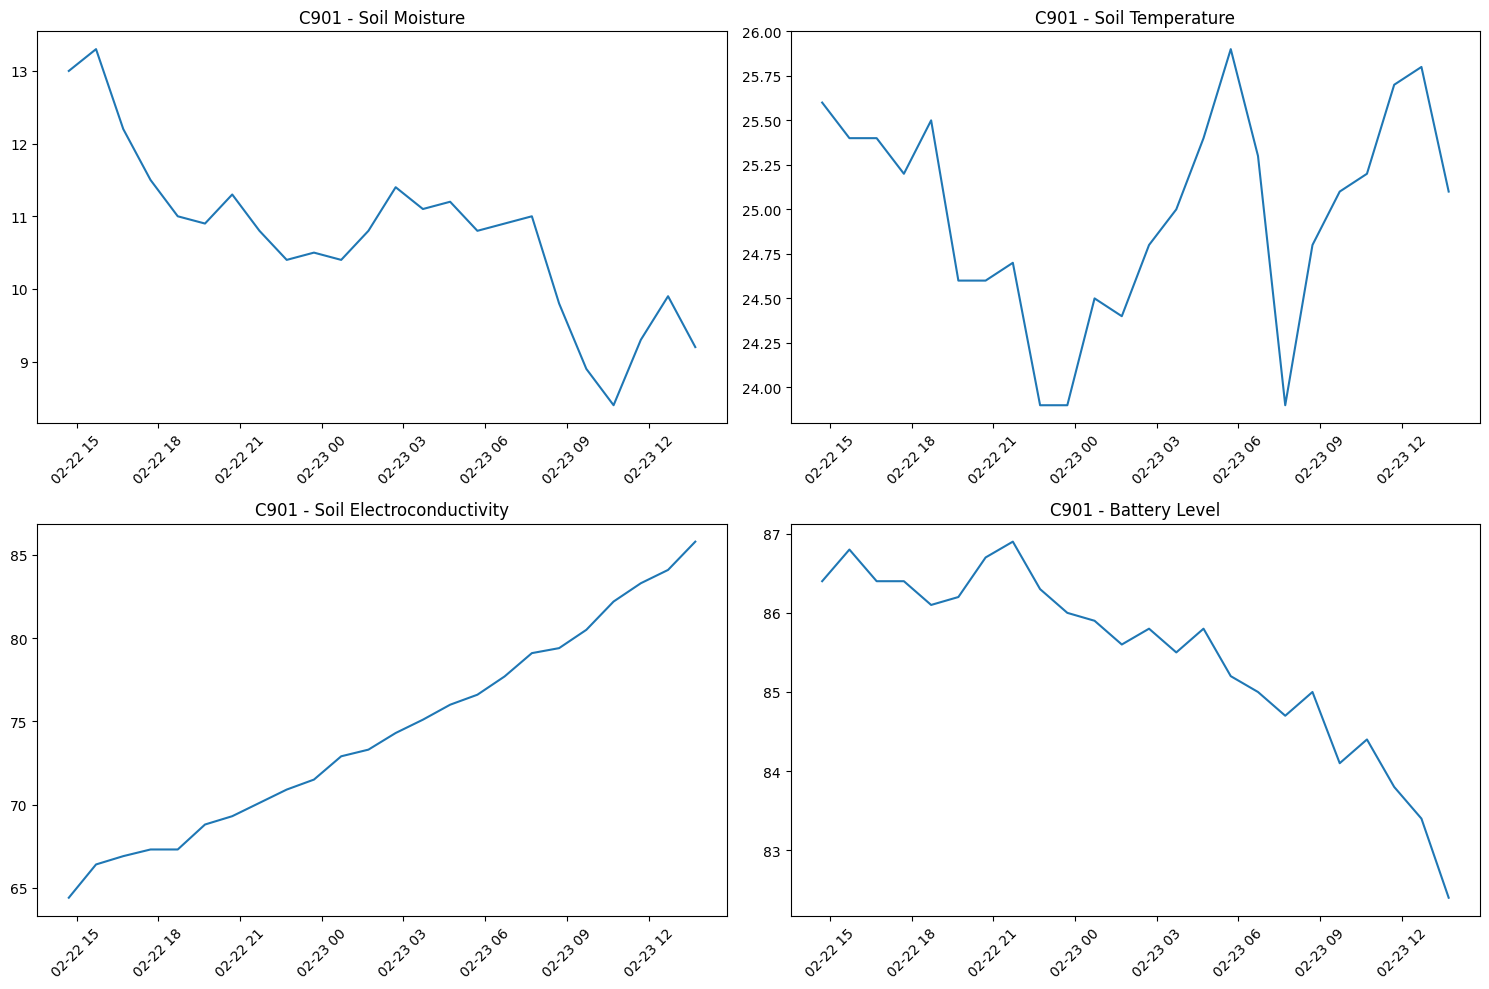

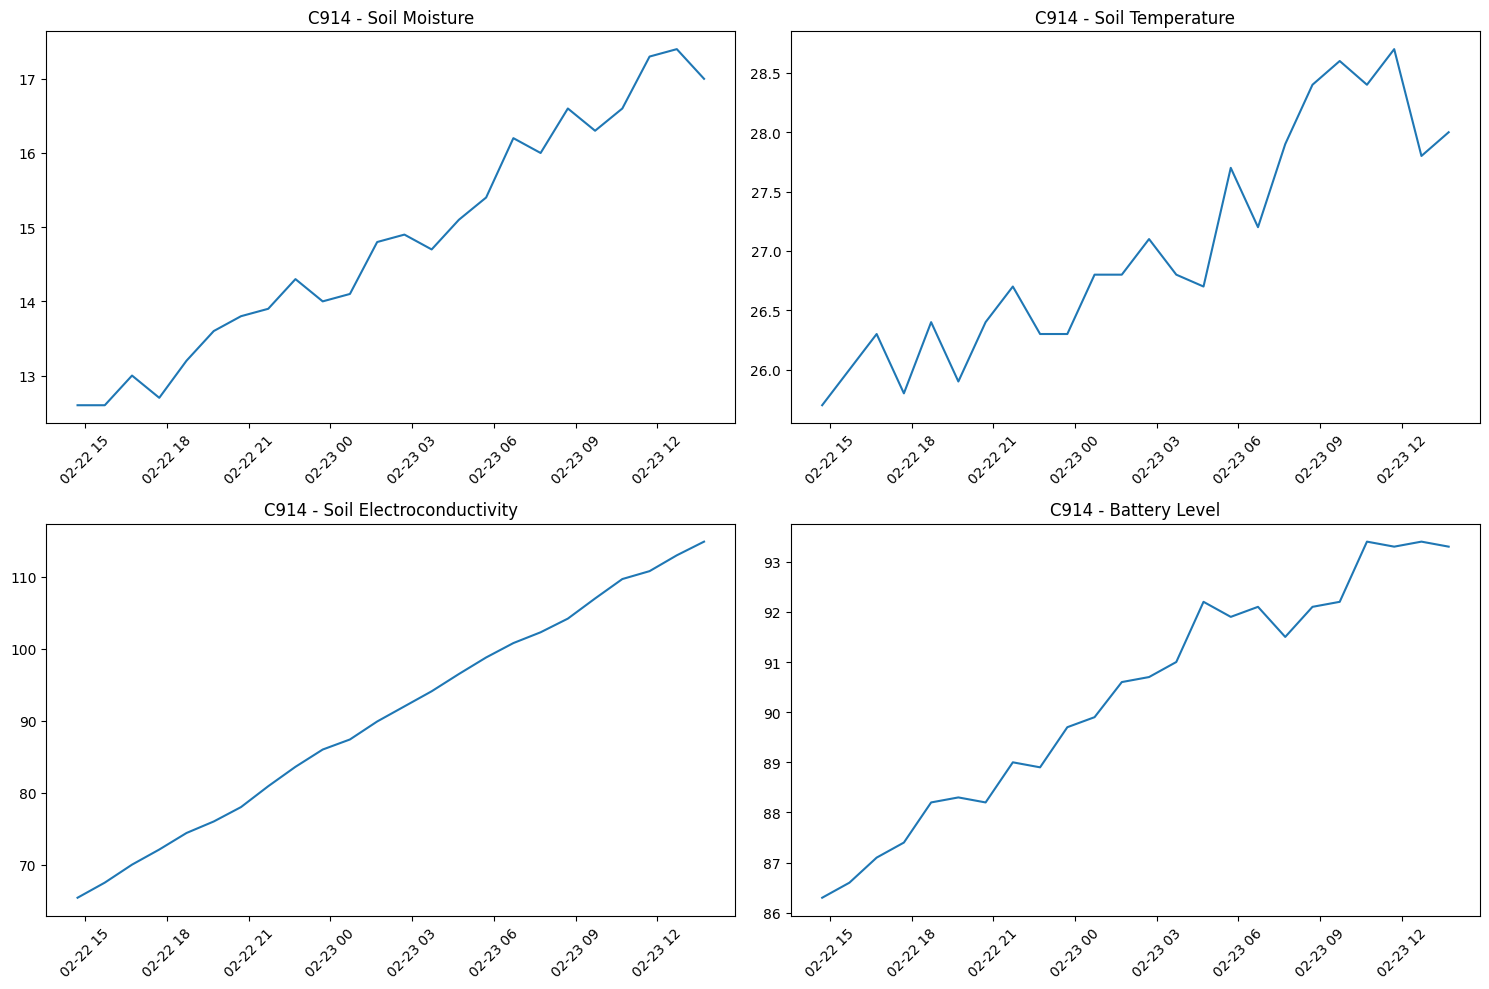

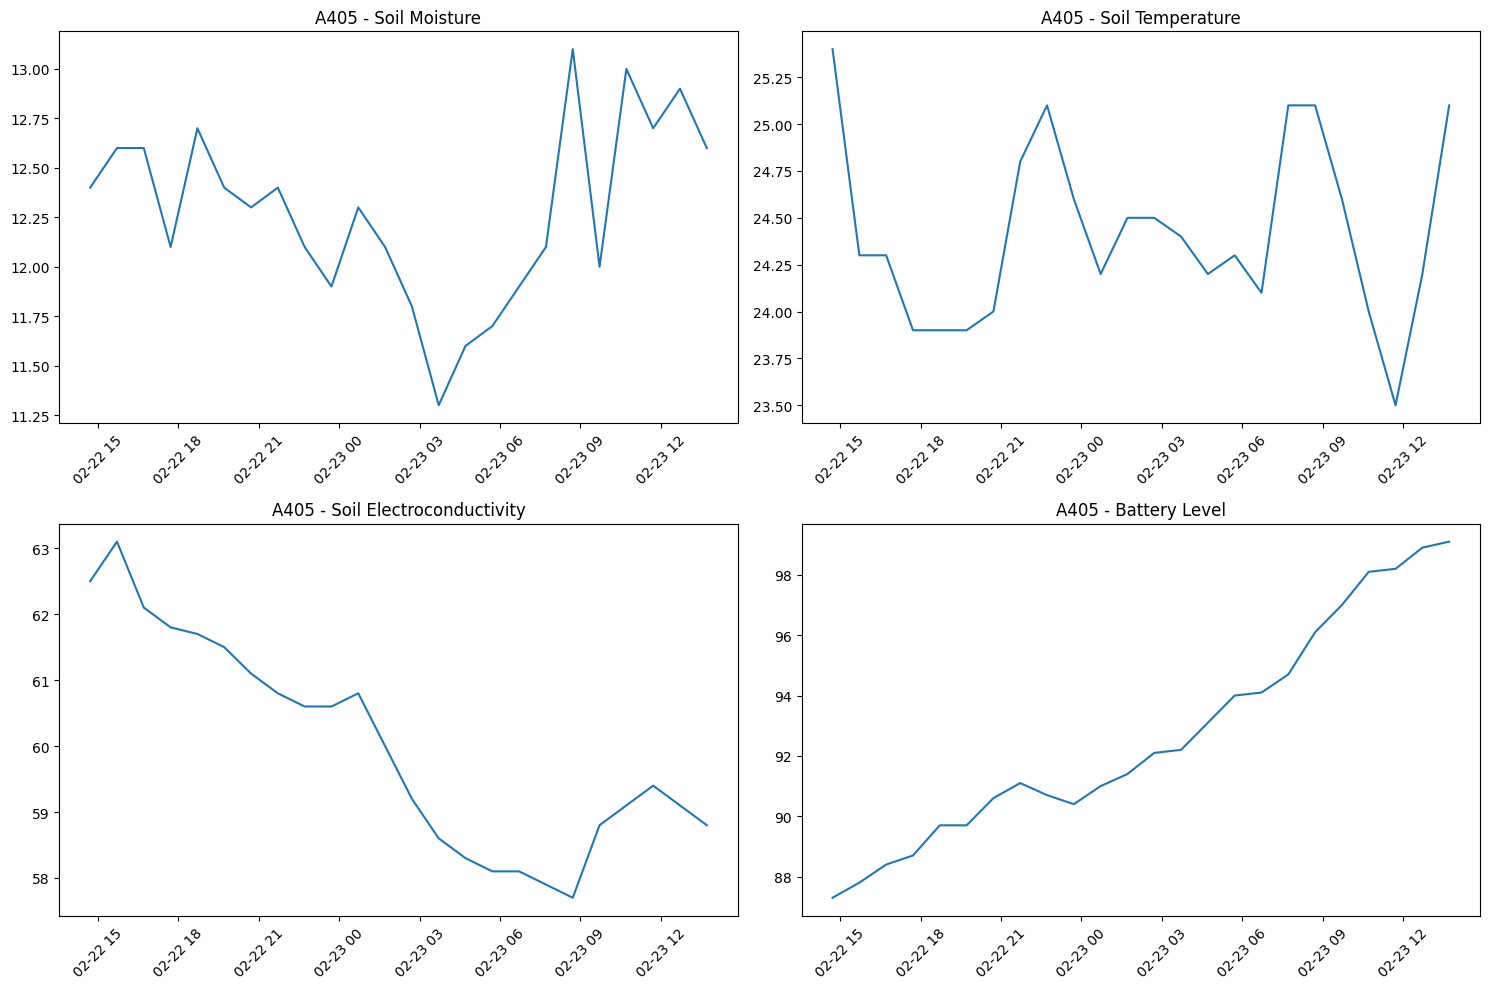

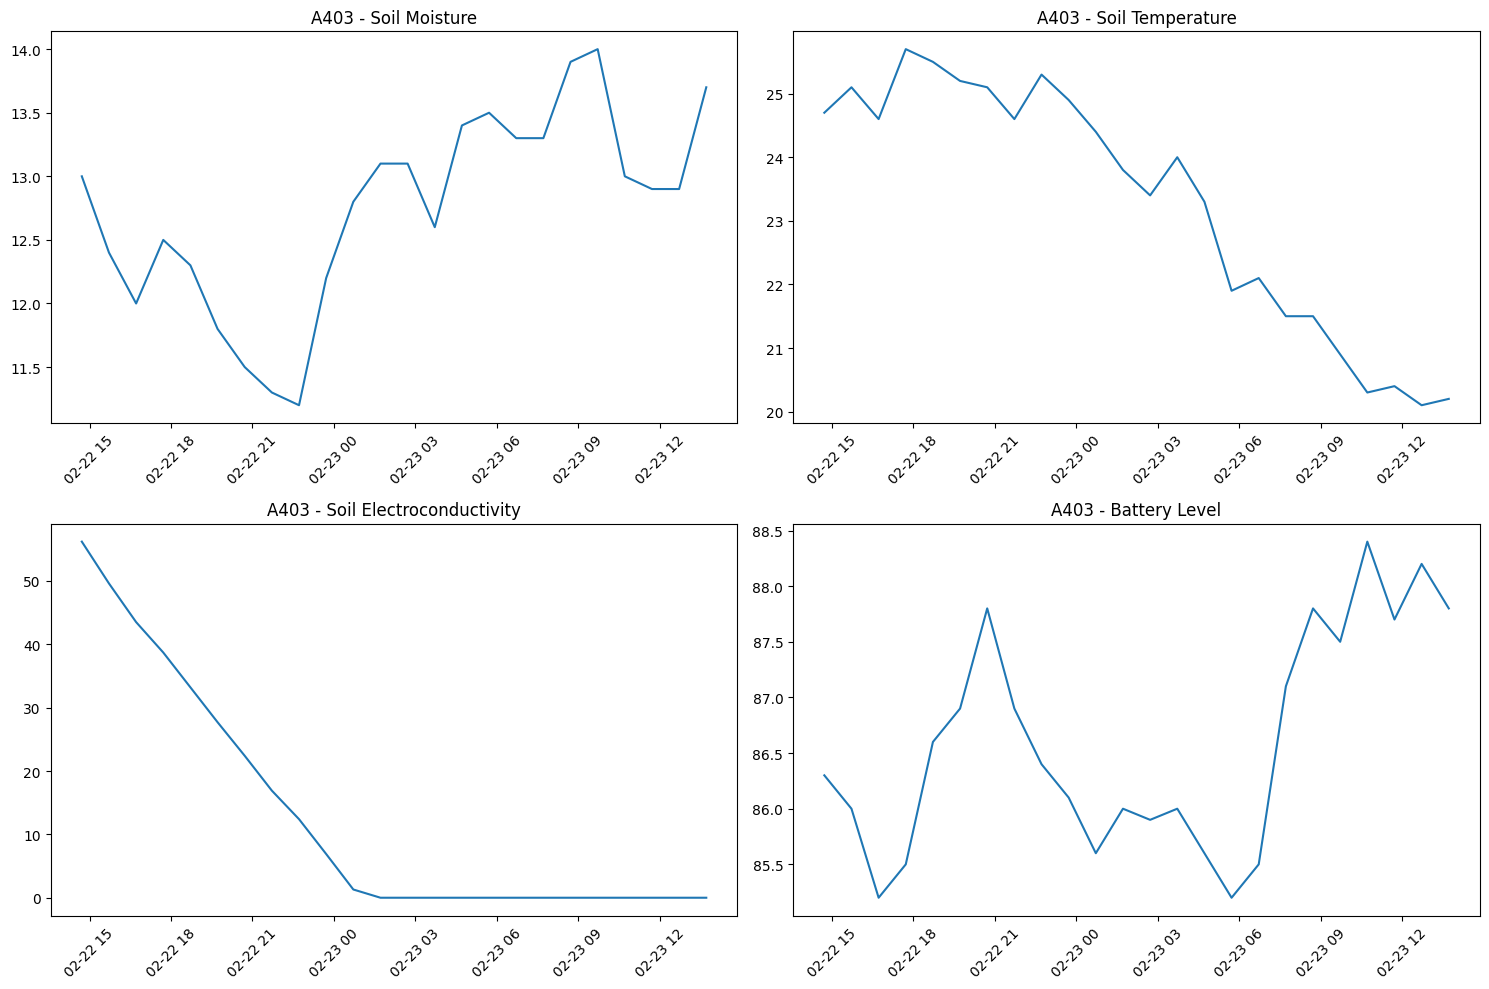

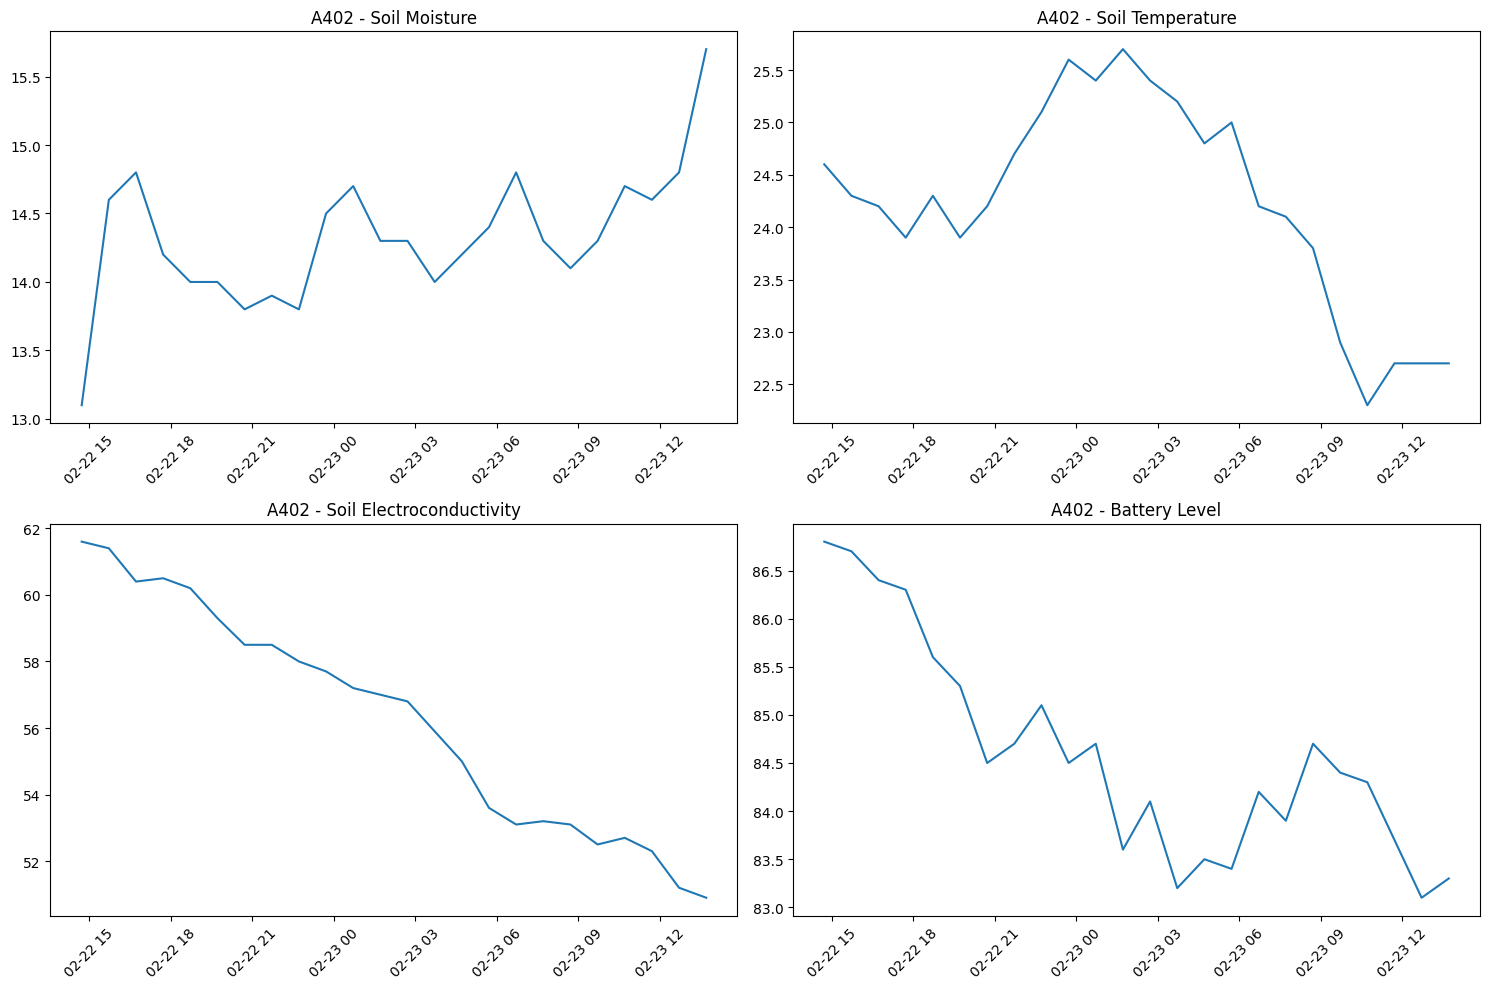

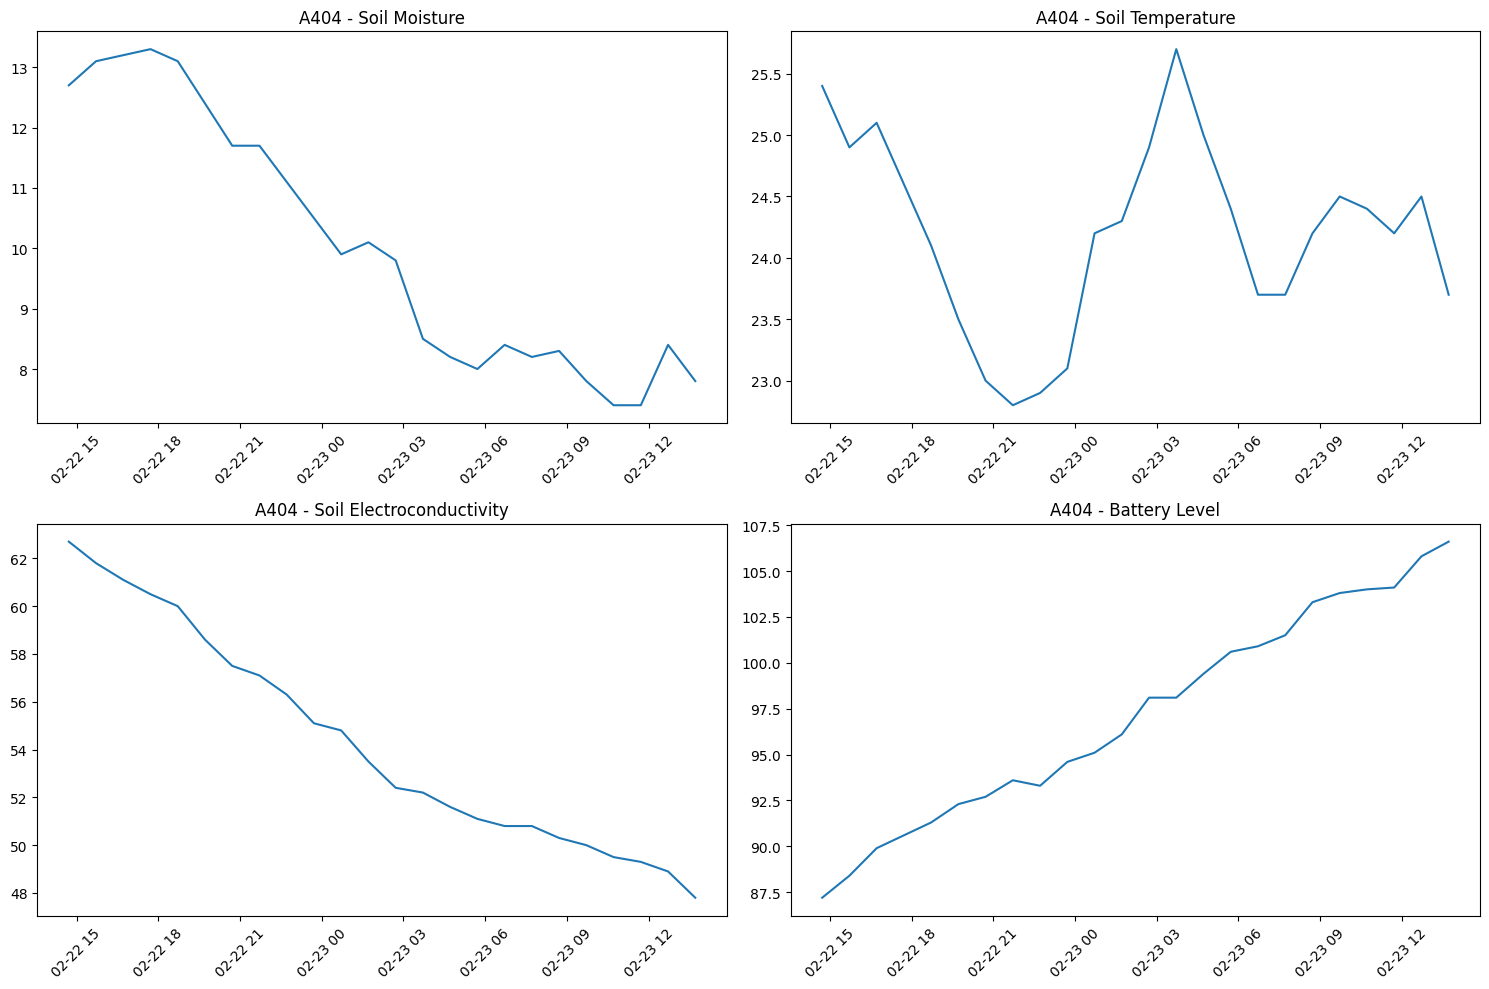

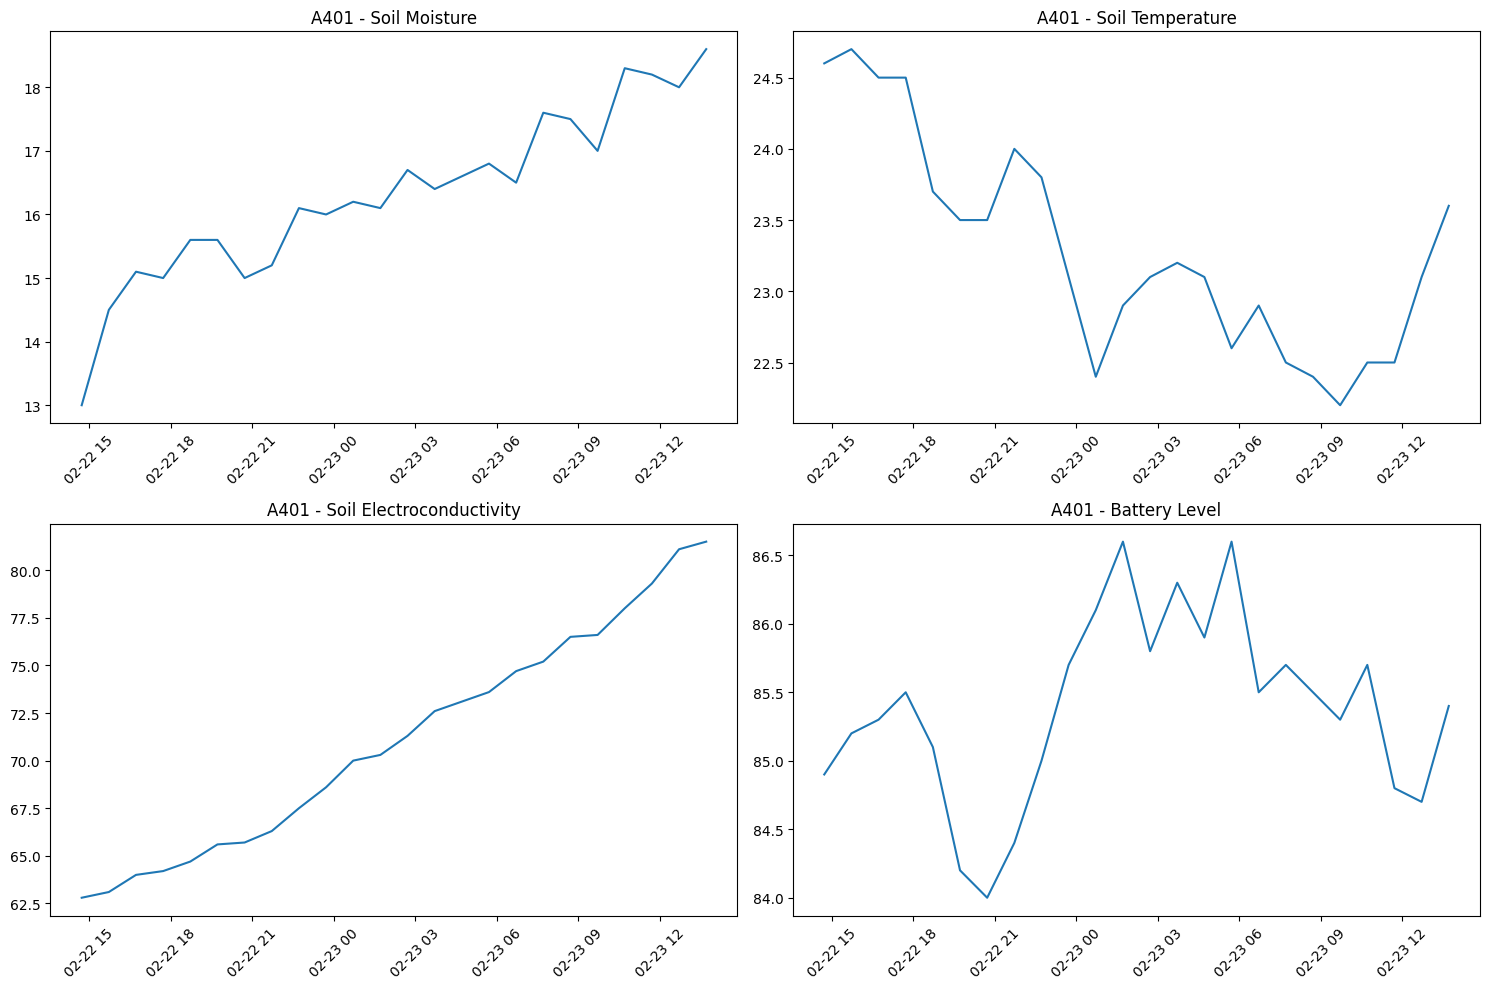

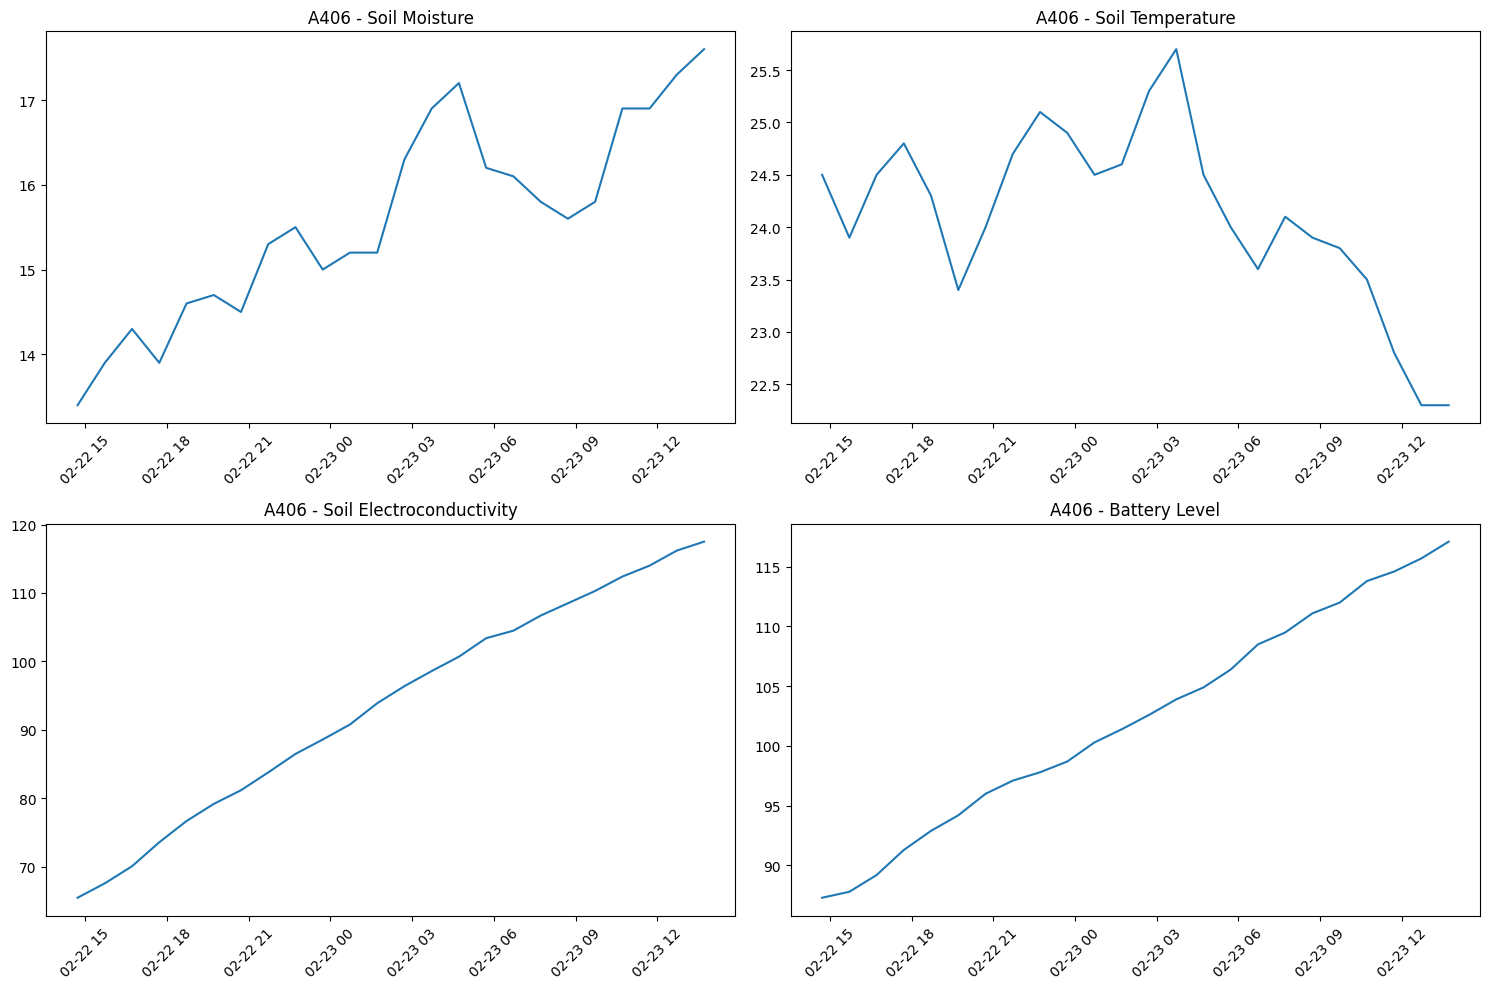

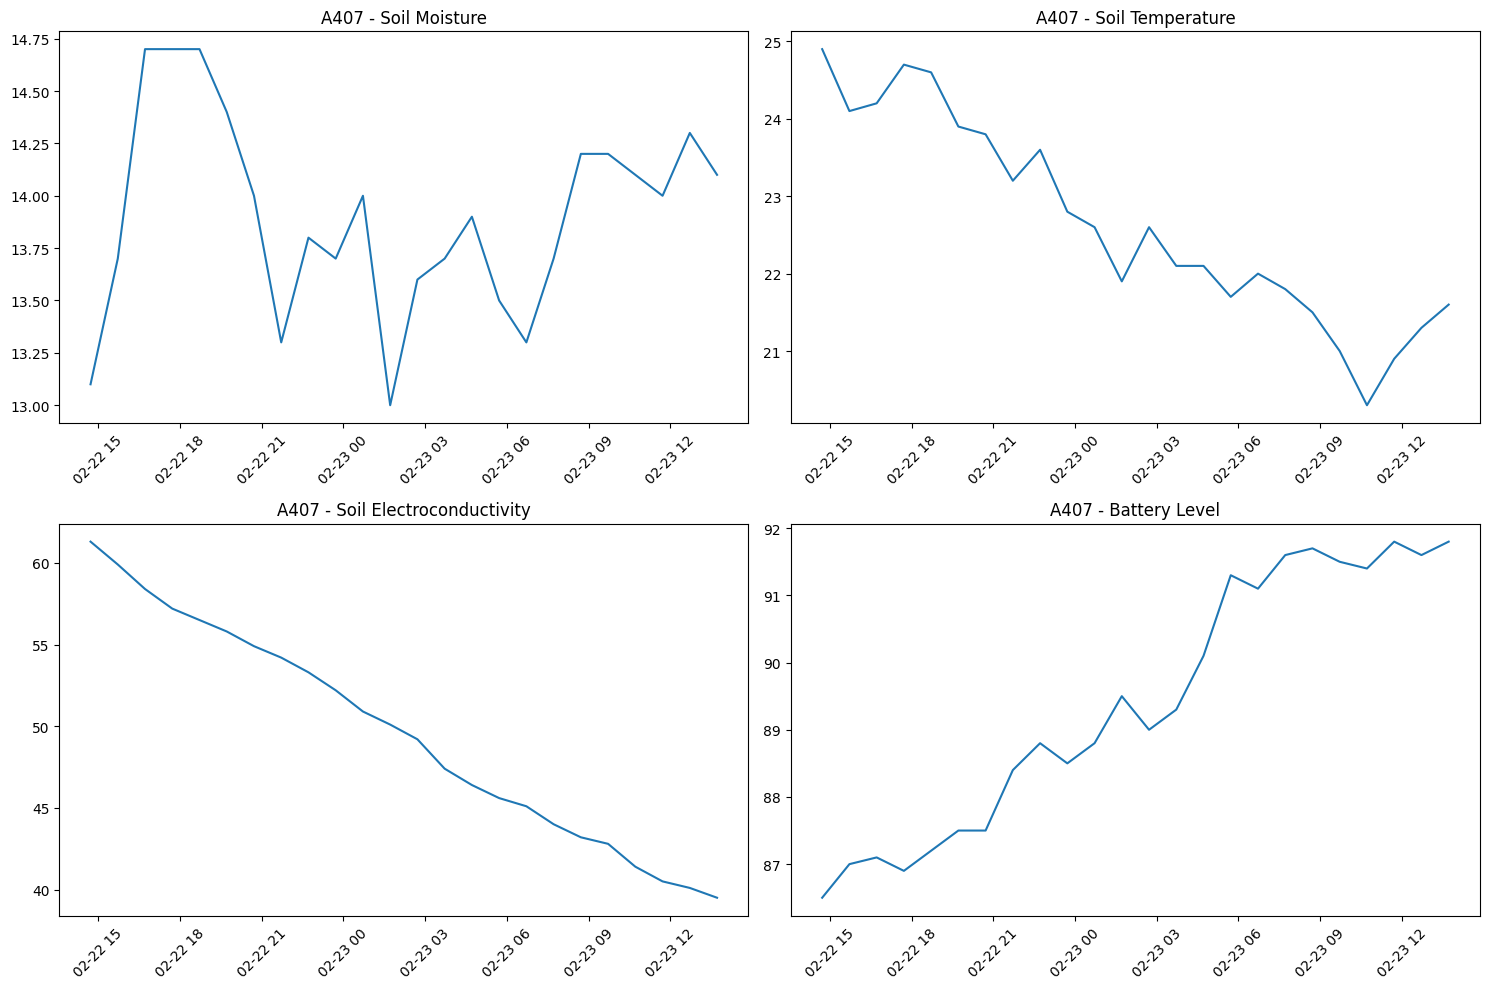

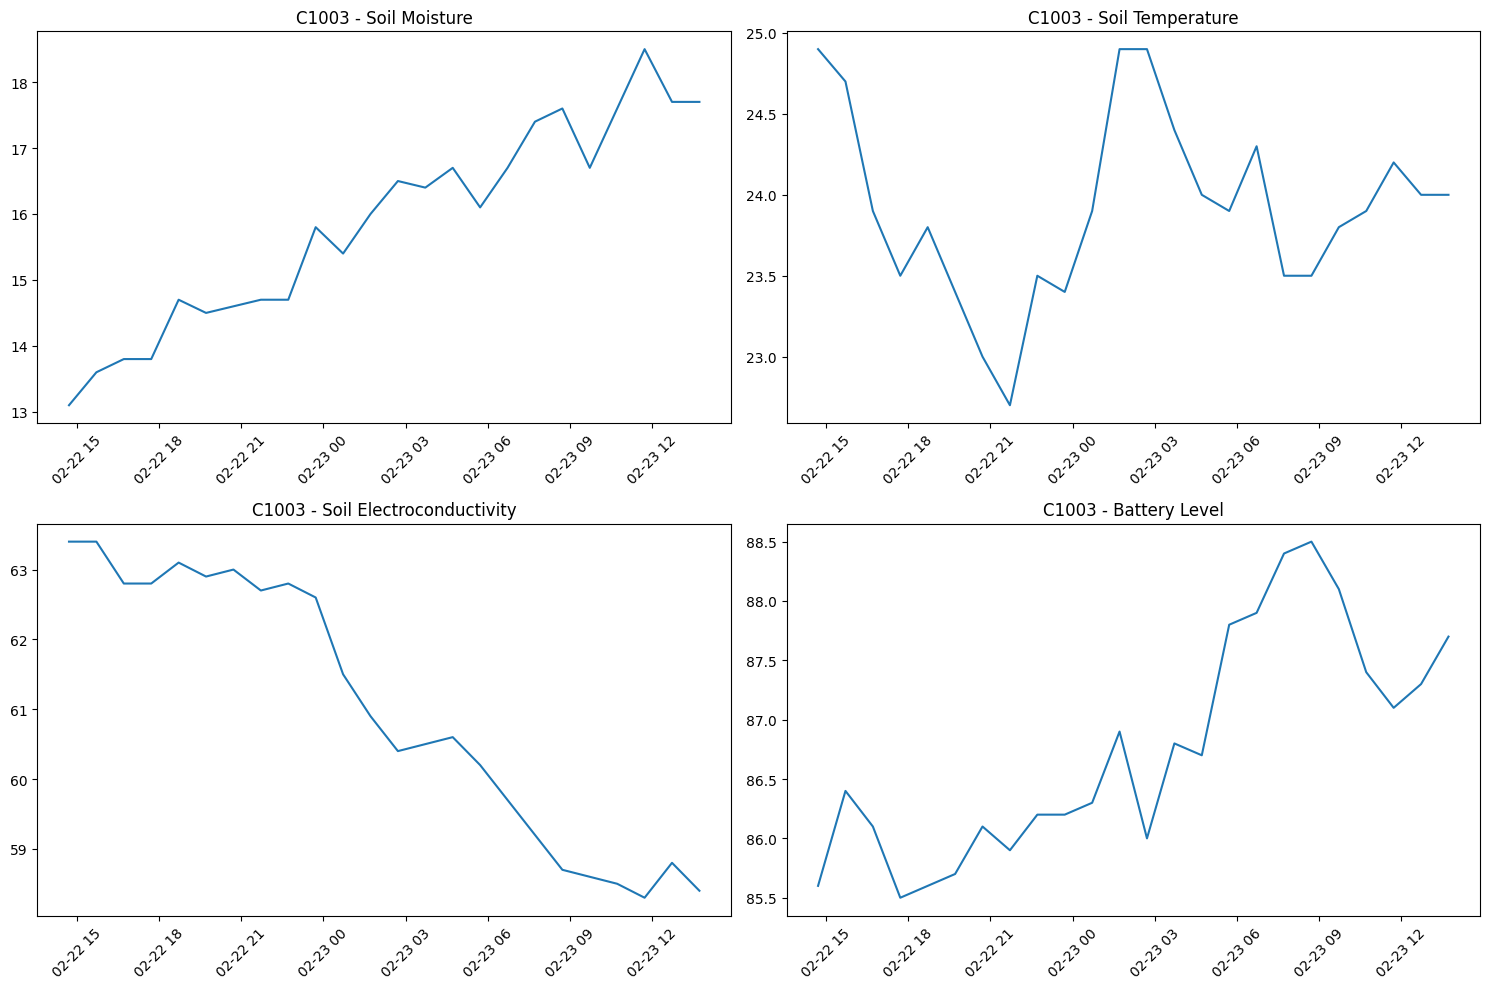

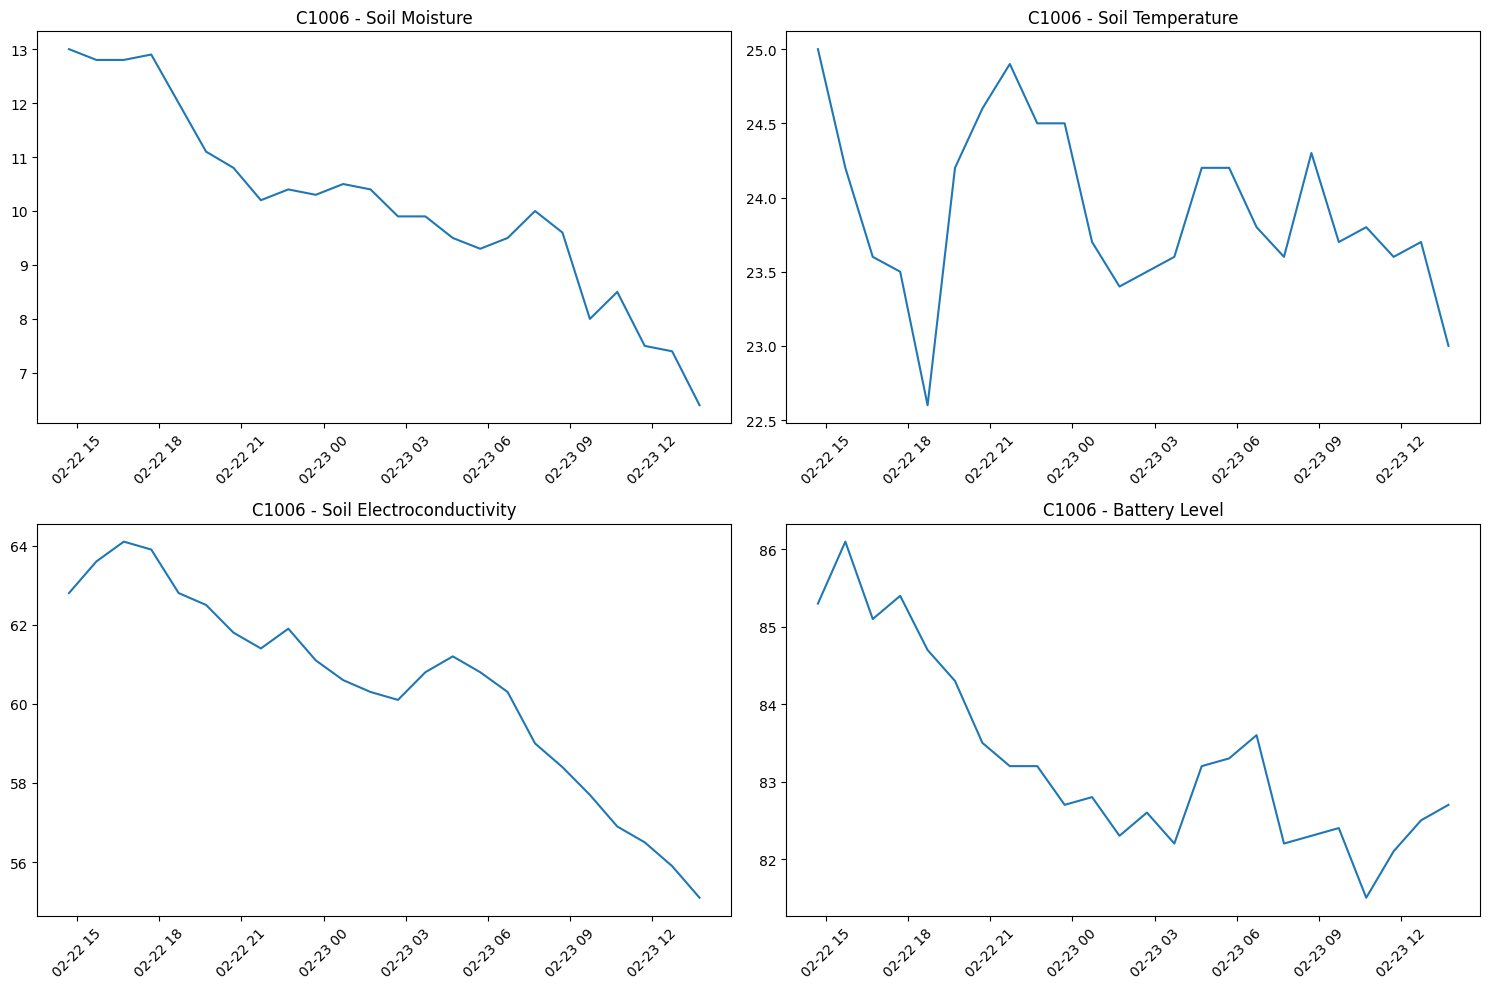

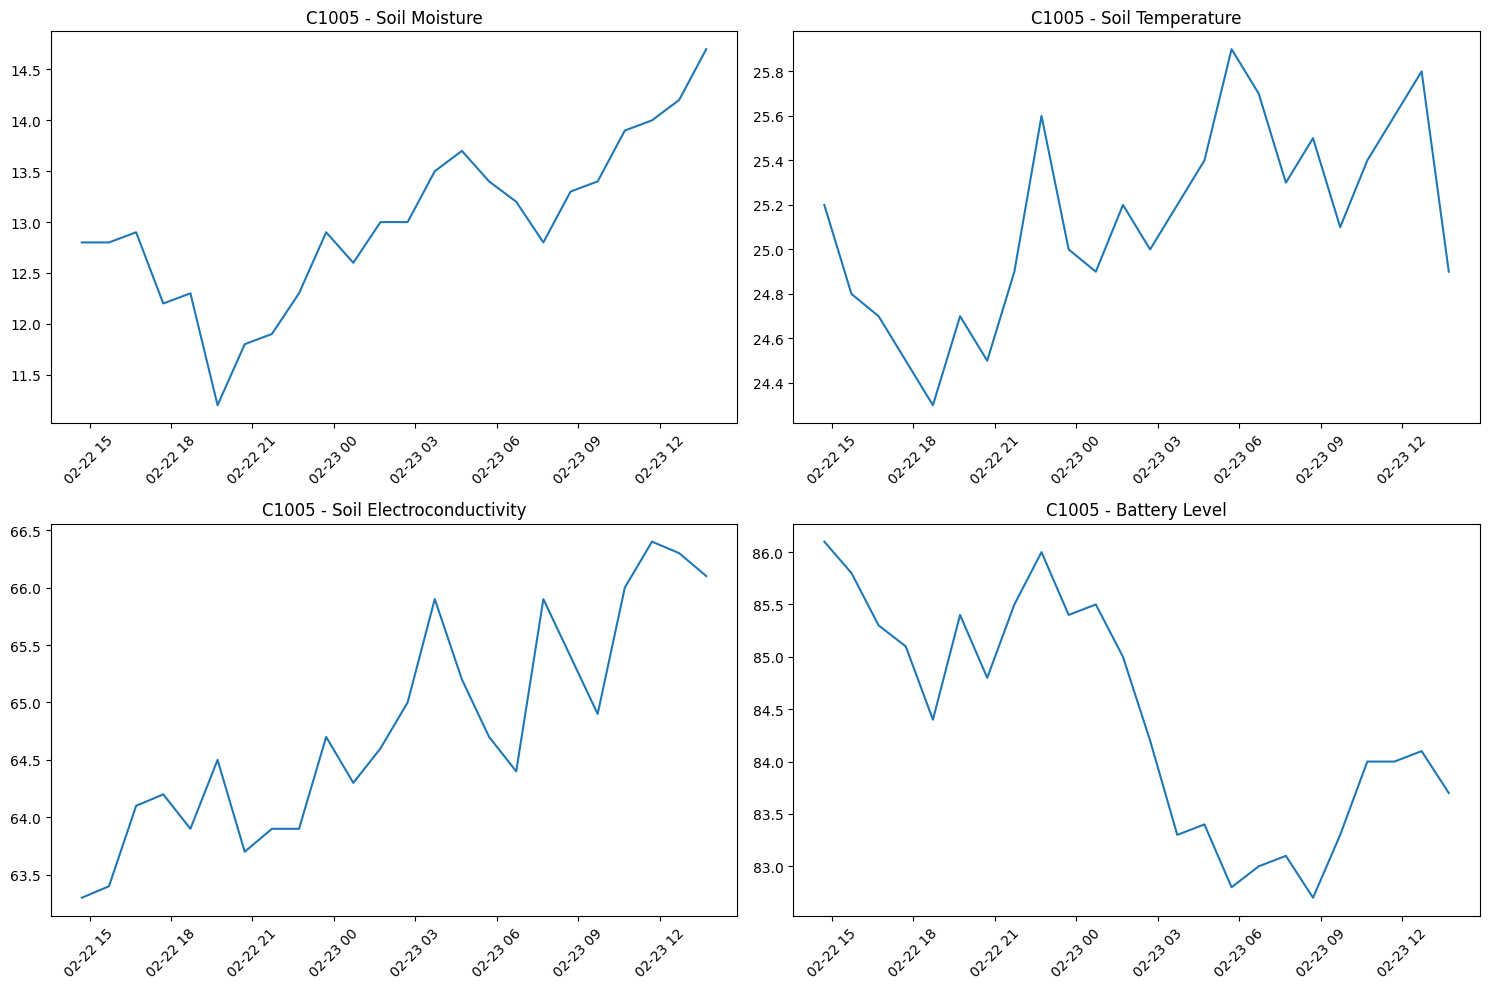

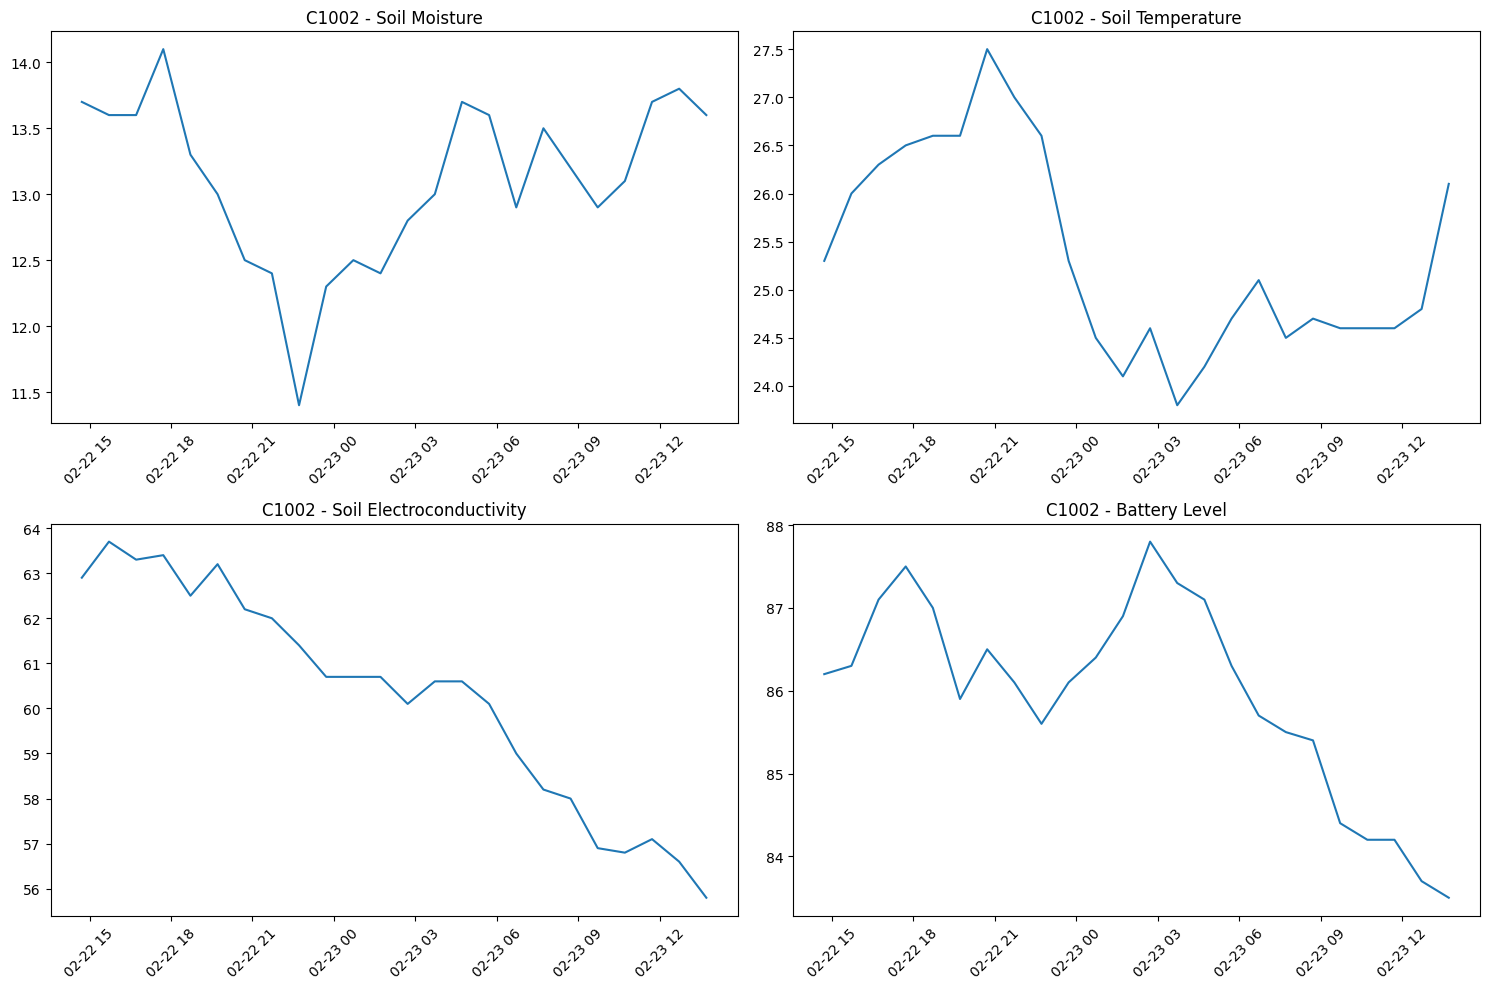

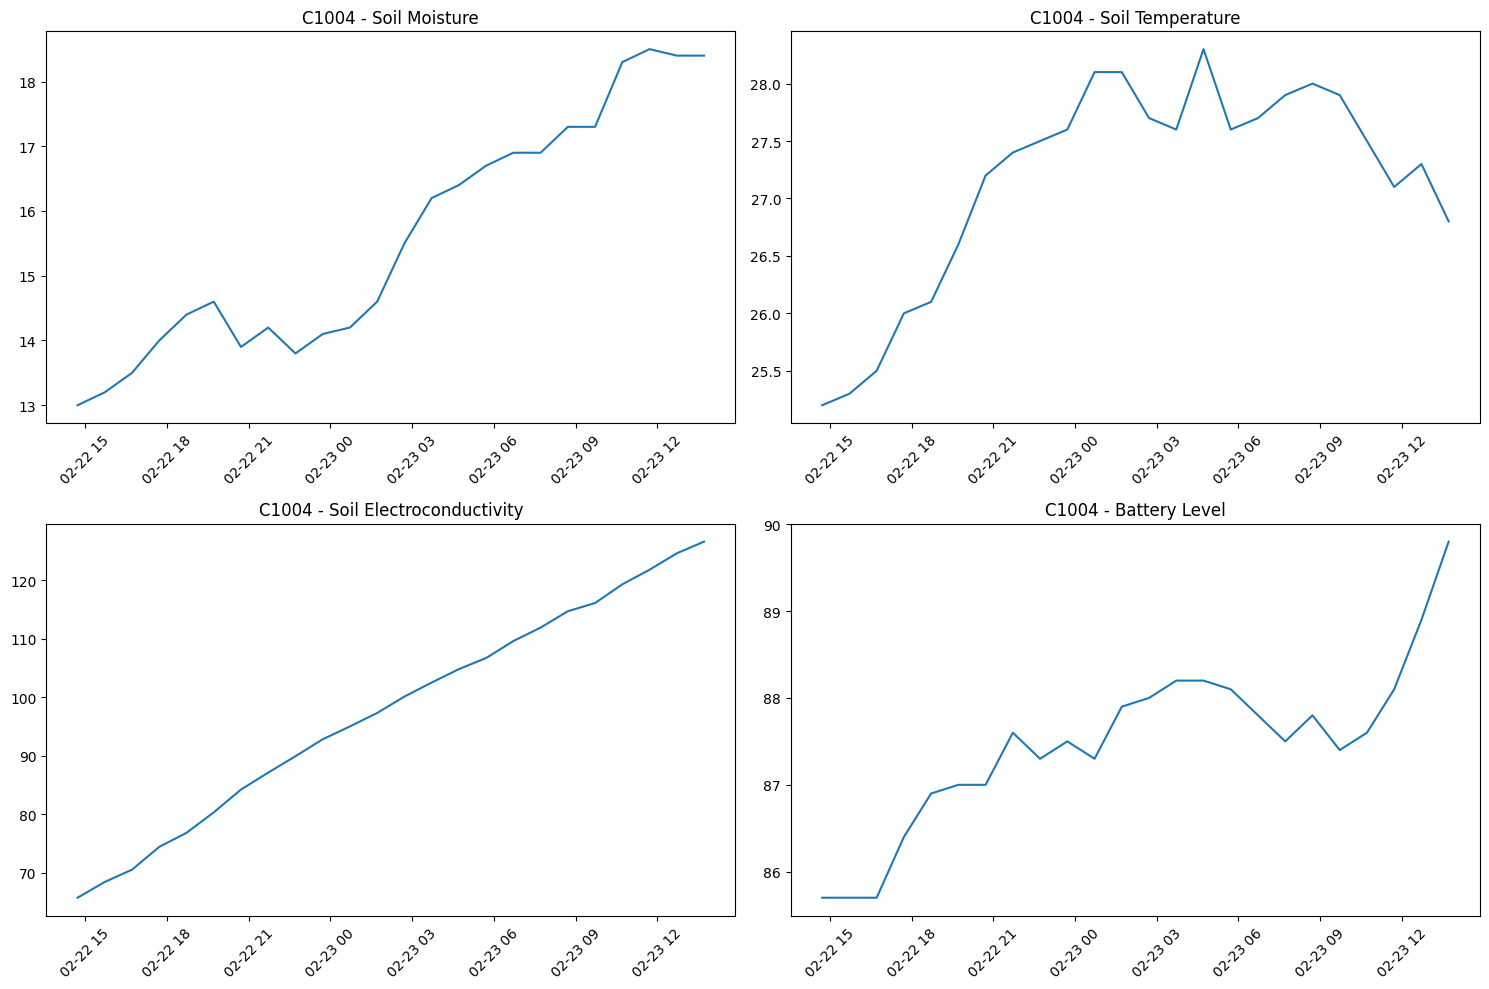

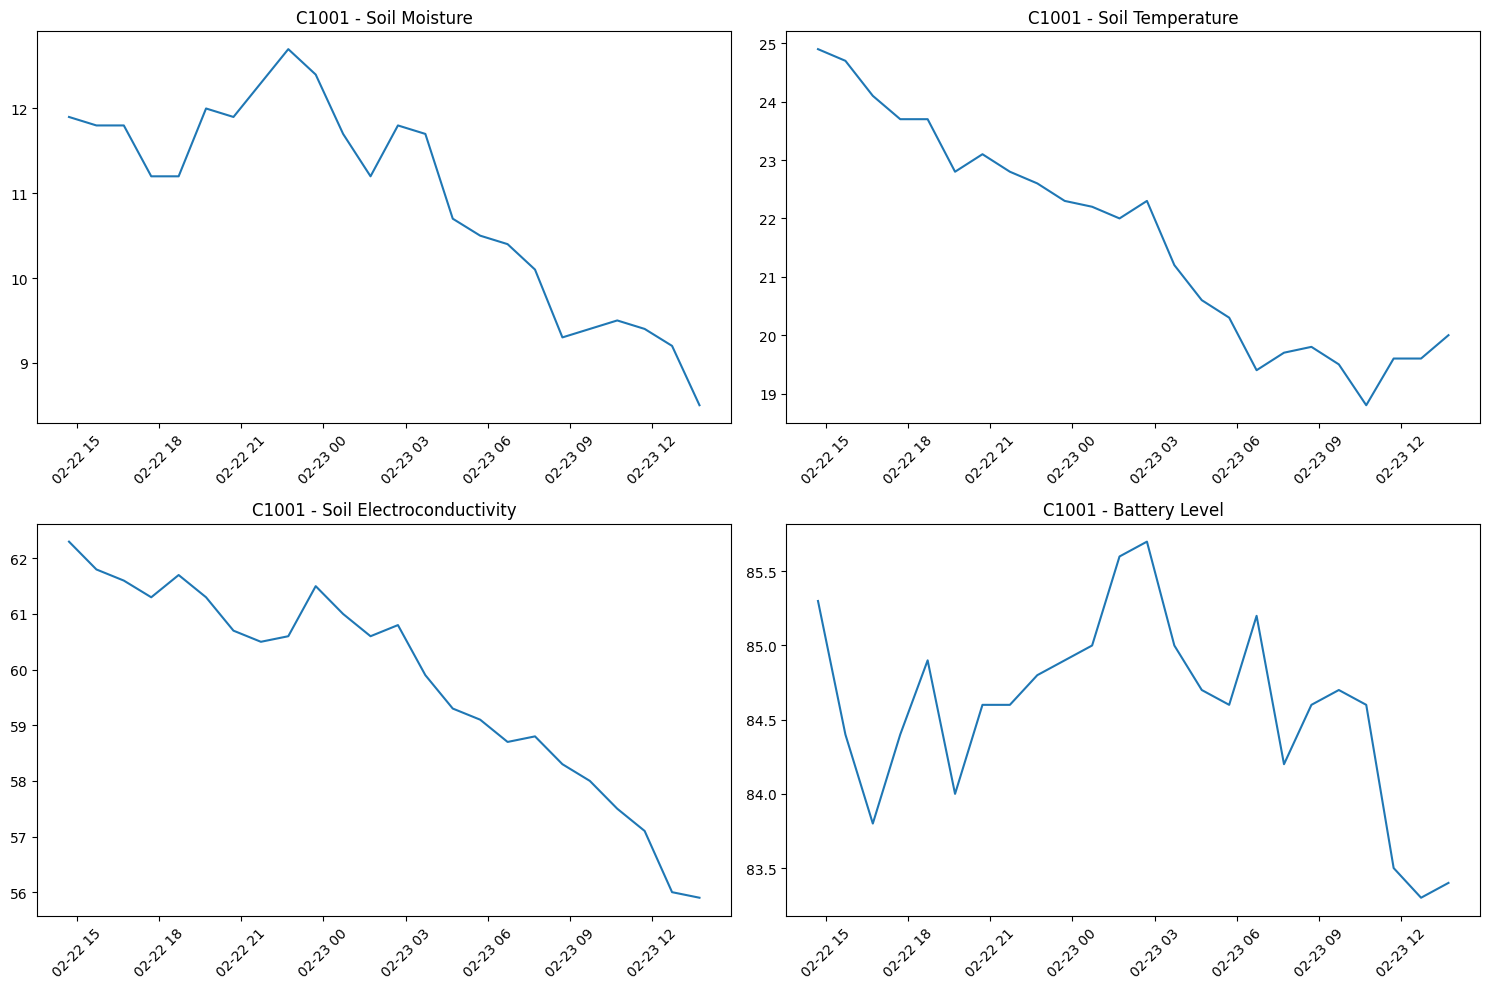

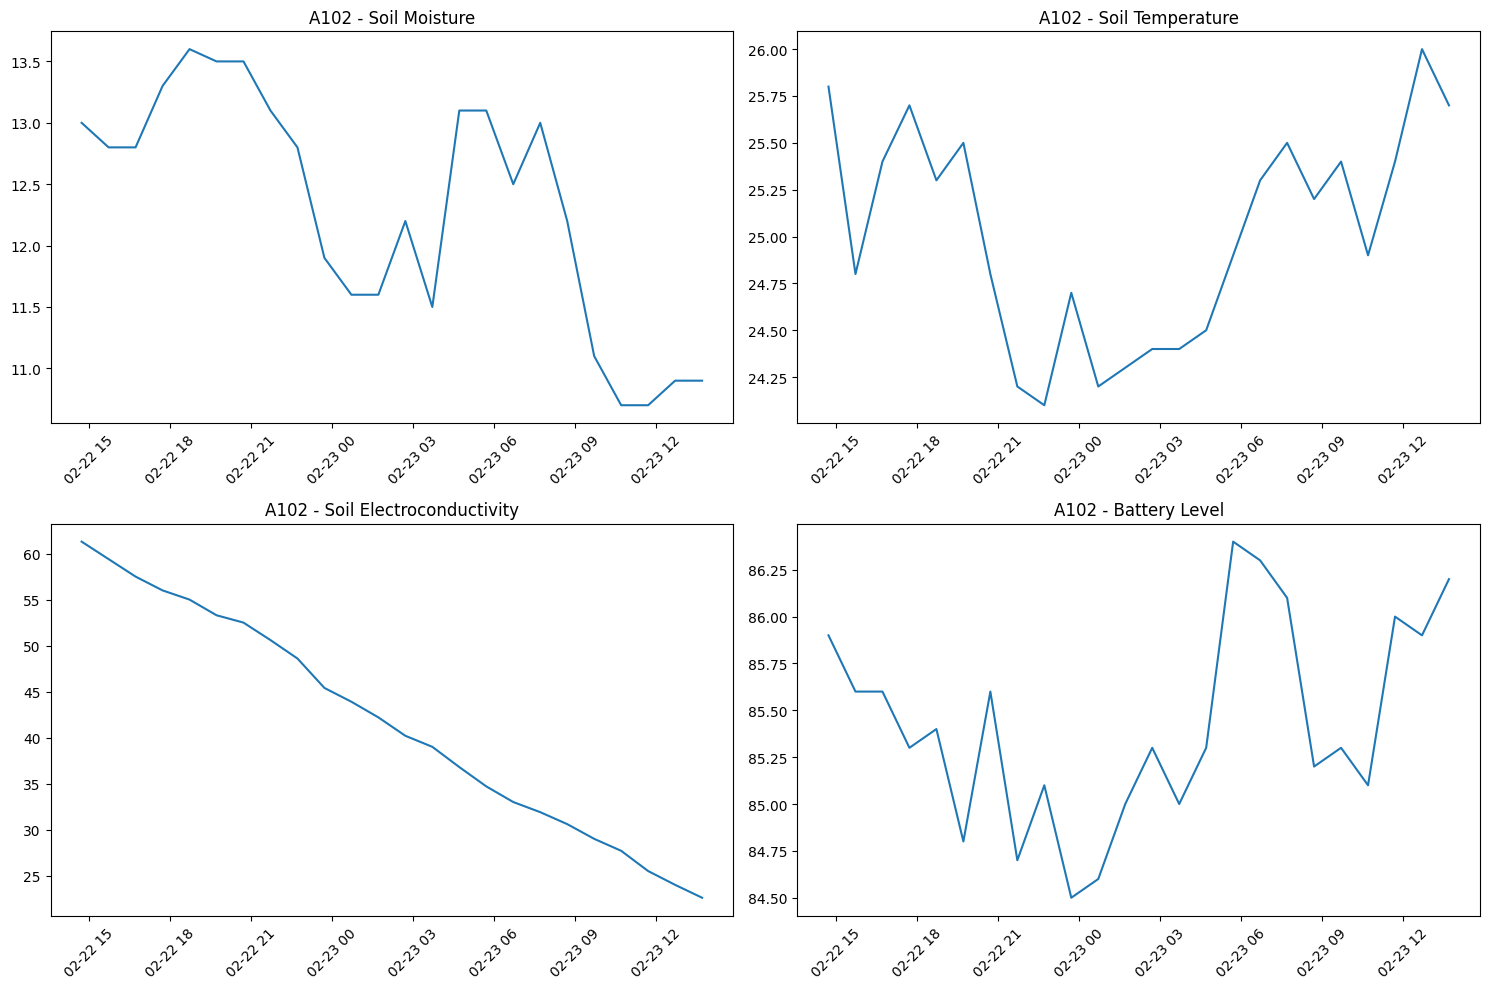

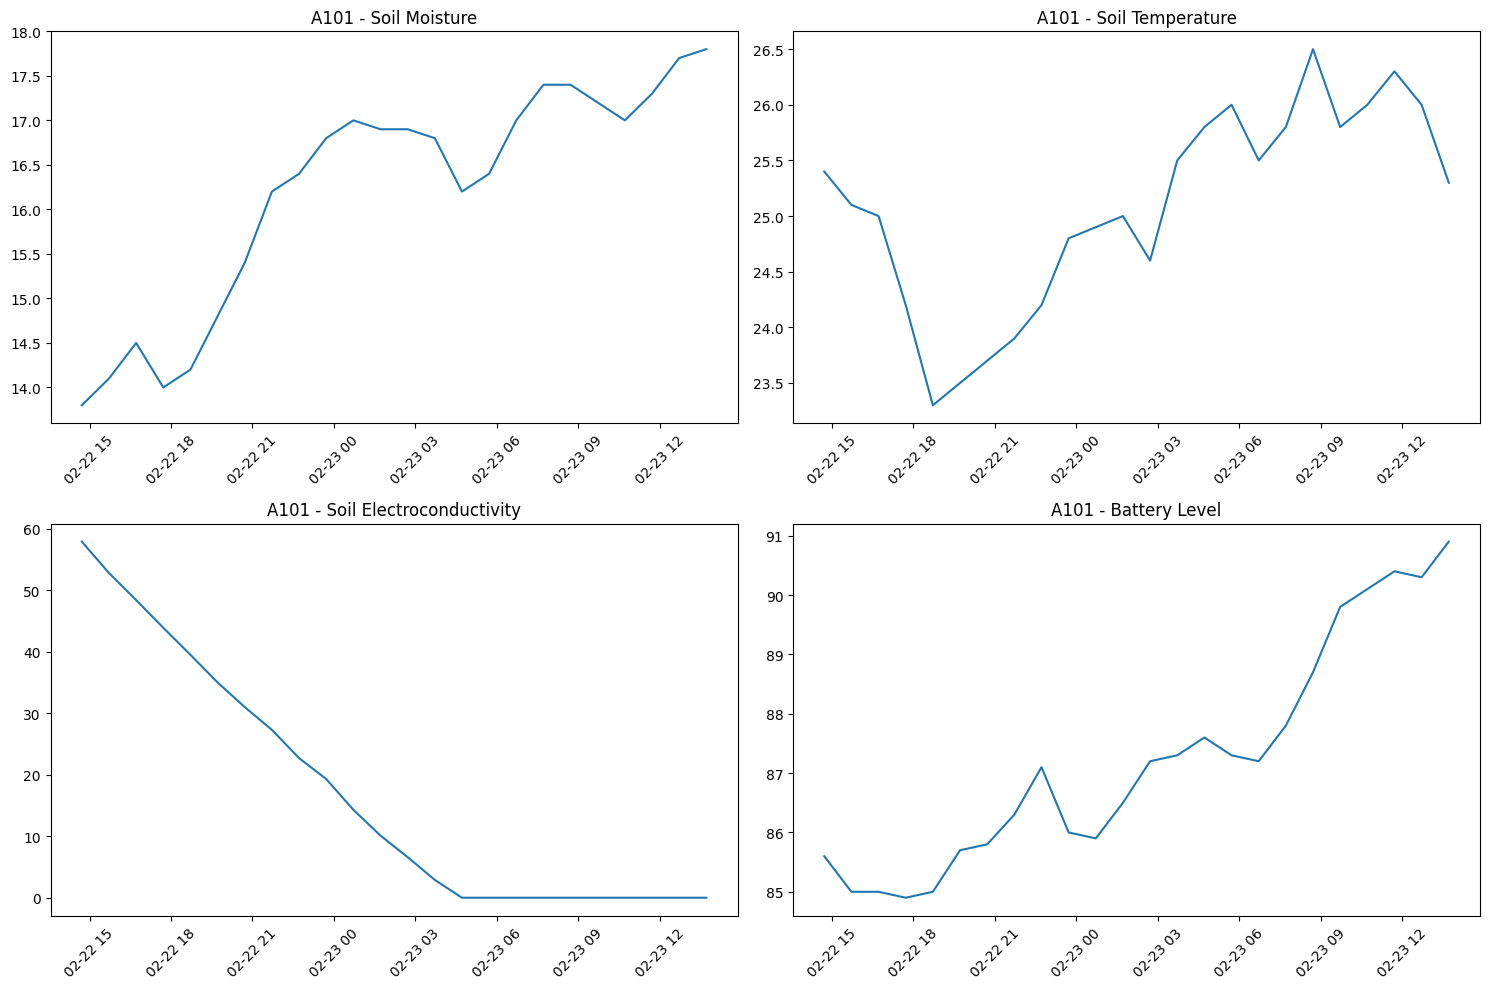

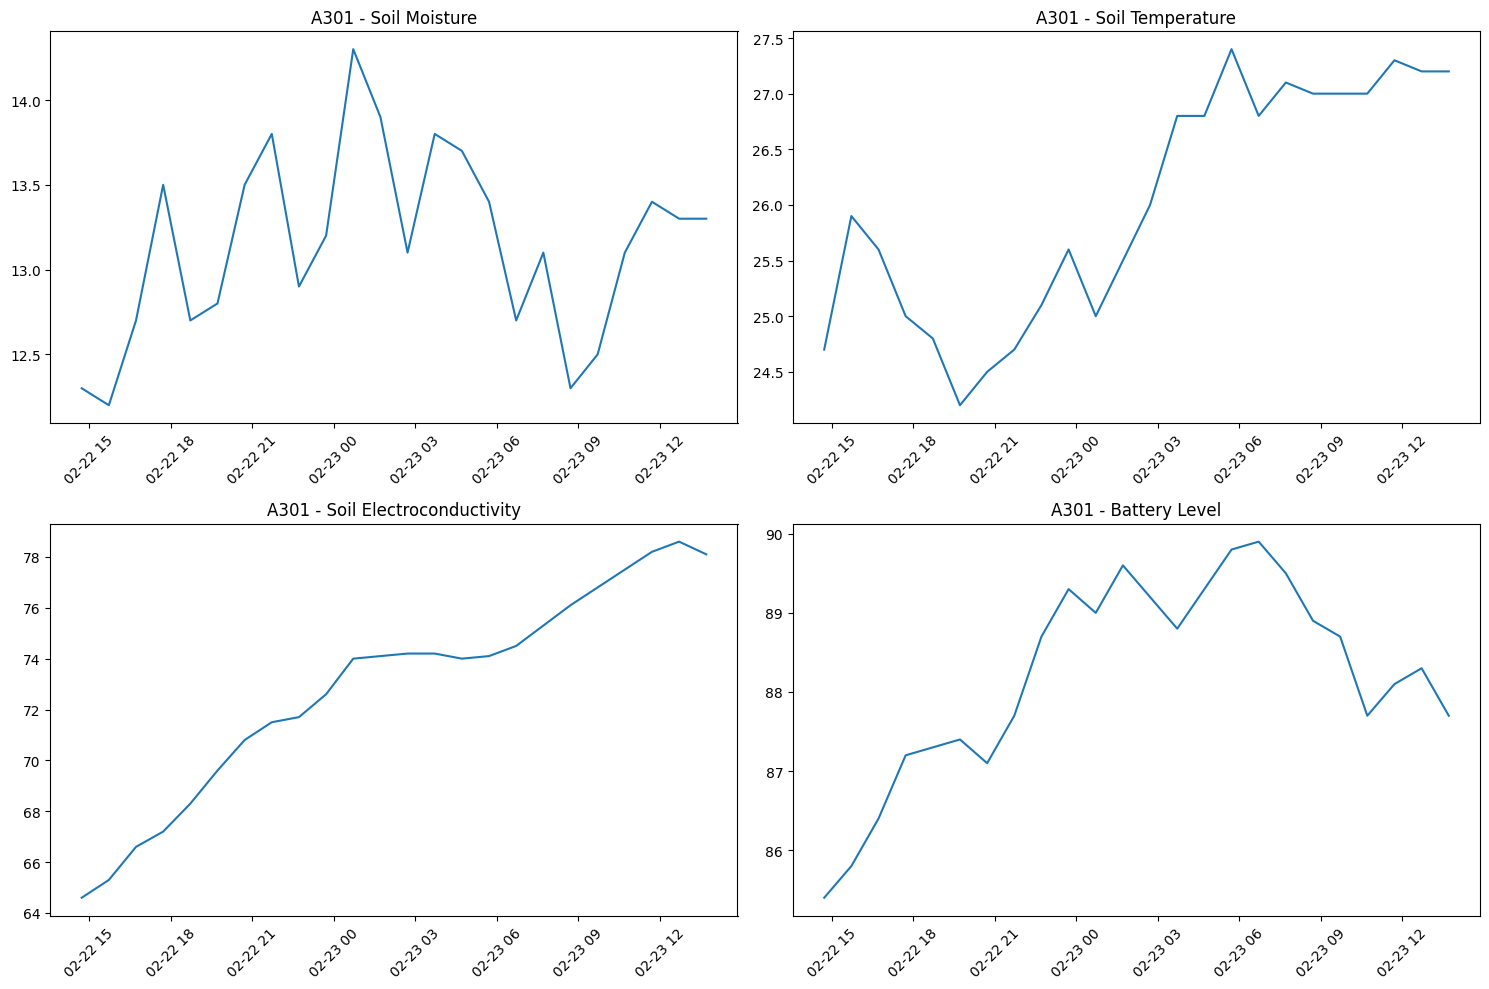

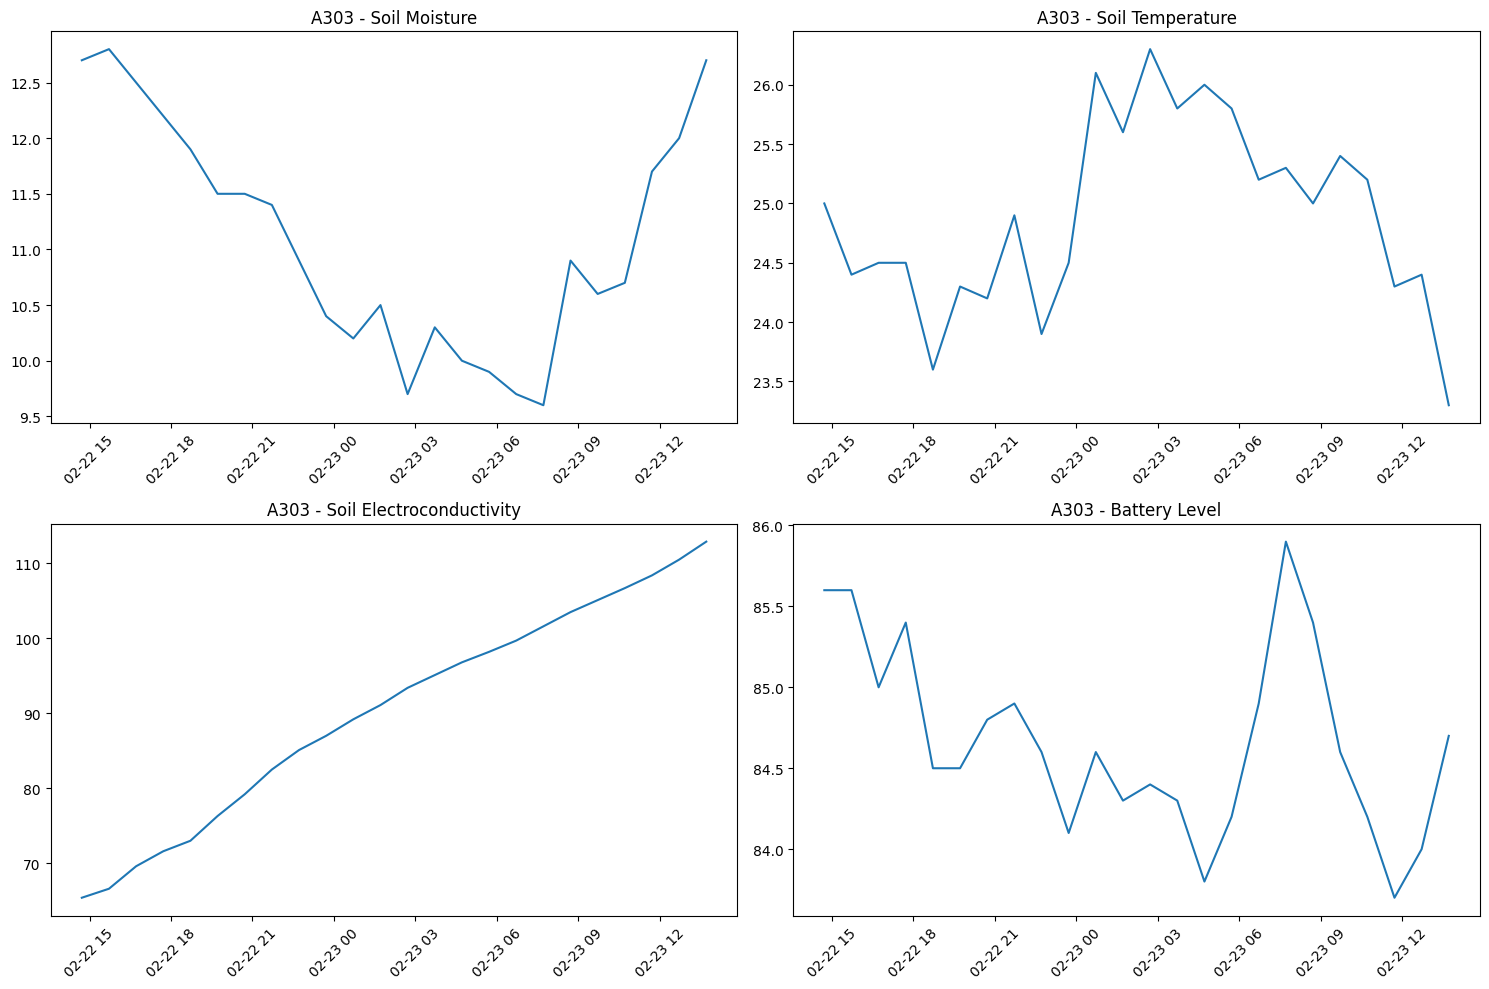

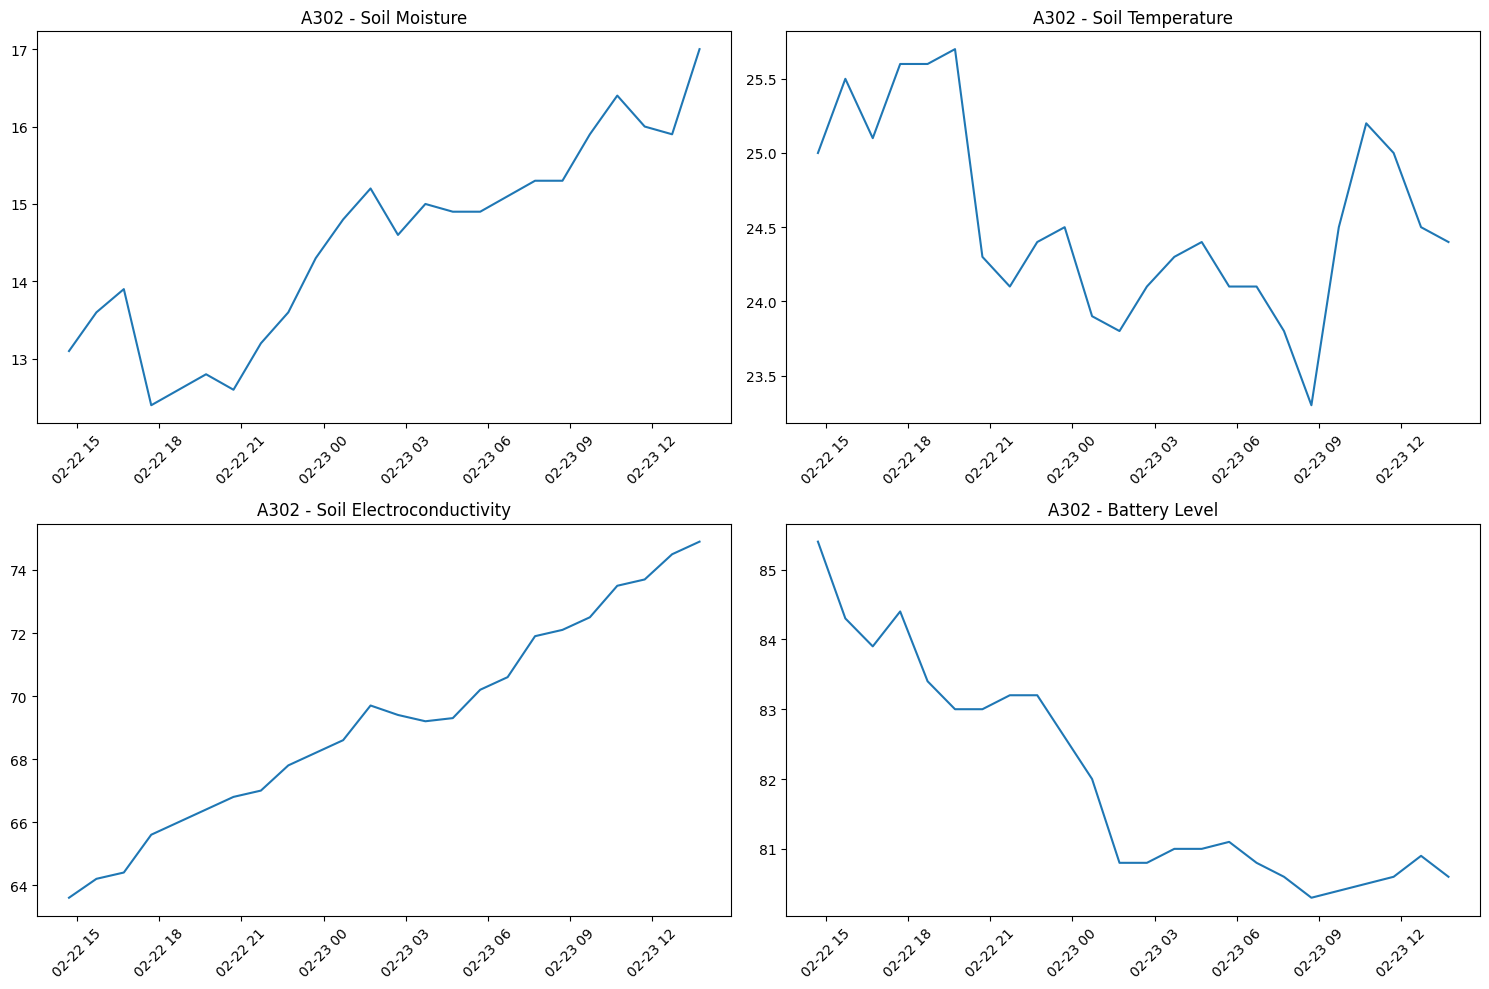

In [14]:
for sensor_id in simulated_data['sensor_id'].unique():
    sensor_data = simulated_data[simulated_data['sensor_id'] == sensor_id]
    
    plt.figure(figsize=(15, 10))
    
    plt.subplot(2, 2, 1)
    plt.plot(sensor_data['createdAt'], sensor_data['soil_moisture'])
    plt.title(f'{sensor_id} - Soil Moisture')
    plt.xticks(rotation=45)
    
    plt.subplot(2, 2, 2)
    plt.plot(sensor_data['createdAt'], sensor_data['soil_temperature'])
    plt.title(f'{sensor_id} - Soil Temperature')
    plt.xticks(rotation=45)
    
    plt.subplot(2, 2, 3)
    plt.plot(sensor_data['createdAt'], sensor_data['soil_electrocoductivity'])
    plt.title(f'{sensor_id} - Soil Electroconductivity')
    plt.xticks(rotation=45)
    
    plt.subplot(2, 2, 4)
    plt.plot(sensor_data['createdAt'], sensor_data['battery_level'])
    plt.title(f'{sensor_id} - Battery Level')
    plt.xticks(rotation=45)
    
    plt.tight_layout()
    plt.show()

In [43]:
ls

 Volume in drive C is Windows 
 Volume Serial Number is C412-34B0

 Directory of C:\Users\robot\Vault\Spring24\CAPSTONE\Lab2\function-calling-for-sensors-at-the-edge\Data

21/02/2025  12:02    <DIR>          .
21/02/2025  10:51    <DIR>          ..
21/02/2025  10:52    <DIR>          .ipynb_checkpoints
06/02/2025  08:45           402,750 August-October-2021-sectionA1-data.csv
06/02/2025  08:45           980,663 August-October-2021-sectionA2-data.csv
06/02/2025  08:45           853,090 August-October-2021-sectionA3-data.csv
06/02/2025  08:45         1,671,416 August-October-2021-sectionA4-data.csv
06/02/2025  08:45         1,607,282 August-October-2021-sectionC10-data.csv
06/02/2025  08:45         3,932,290 August-October-2021-sectionC9-data.csv
21/02/2025  12:02           342,268 regression.ipynb
               7 File(s)      9,789,759 bytes
               3 Dir(s)  18,386,149,376 bytes free


In [51]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.multioutput import MultiOutputRegressor
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Load the CSV file
df = pd.read_csv("August-October-2021-sectionA1-data.csv")

# Remove irrelevant columns
df.drop(columns=["id", "owner"], inplace=True)

# Convert 'createdAt' to datetime format
df['createdAt'] = pd.to_datetime(df['createdAt'])
# df['datetime'] = pd.to_datetime(df['createdAt'])

# Extract time-based features
df['hour'] = df['createdAt'].dt.hour
df['day'] = df['createdAt'].dt.day
df['month'] = df['createdAt'].dt.month
df['weekday'] = df['createdAt'].dt.weekday

# Features and target variables
X = df[['soil_moisture', 'soil_temperature', 'soil_electrocoductivity', 'battery_level', 'hour', 'day', 'month', 'weekday', 'sensor_id']]
y = df[['soil_moisture', 'soil_temperature', 'soil_electrocoductivity', 'battery_level']]

# One-hot encode 'sensor_id'
preprocessor = ColumnTransformer(
    transformers=[('sensor_id', OneHotEncoder(handle_unknown='ignore'), ['sensor_id'])],
    remainder='passthrough'
)

# Build the pipeline
model = Pipeline([
    ('preprocessor', preprocessor),
    ('regressor', MultiOutputRegressor(LinearRegression()))
])

# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# Train the model
model.fit(X_train, y_train)

# Make predictions and evaluate
predictions = model.predict(X_test)
mae = mean_absolute_error(y_test, predictions)
mse = mean_squared_error(y_test, predictions)
r2 = r2_score(y_test, predictions)
print(f"Mean Absolute Error: {mae:.2f}")
print(f"MSE: {mse:.2f}")
print(f"R2 Score: {r2:.2f}")


# Generate new simulated data (example)
new_data = pd.DataFrame({
    'soil_moisture': [20],
    'soil_temperature': [22.5],
    'soil_electrocoductivity': [120],
    'battery_level': [90],
    'hour': [10],
    'day': [15],
    'month': [8],
    'weekday': [2],
    'sensor_id': ['A201']
})
simulated_output = model.predict(new_data)

print("\nSimulated Data Output:")
print(simulated_output)

Mean Absolute Error: 0.00
MSE: 0.00
R2 Score: 1.00

Simulated Data Output:
[[ 20.   22.5 120.   90. ]]


Model Evaluation:
MAE: 10.21
MSE: 529.51
R2 Score: 0.54


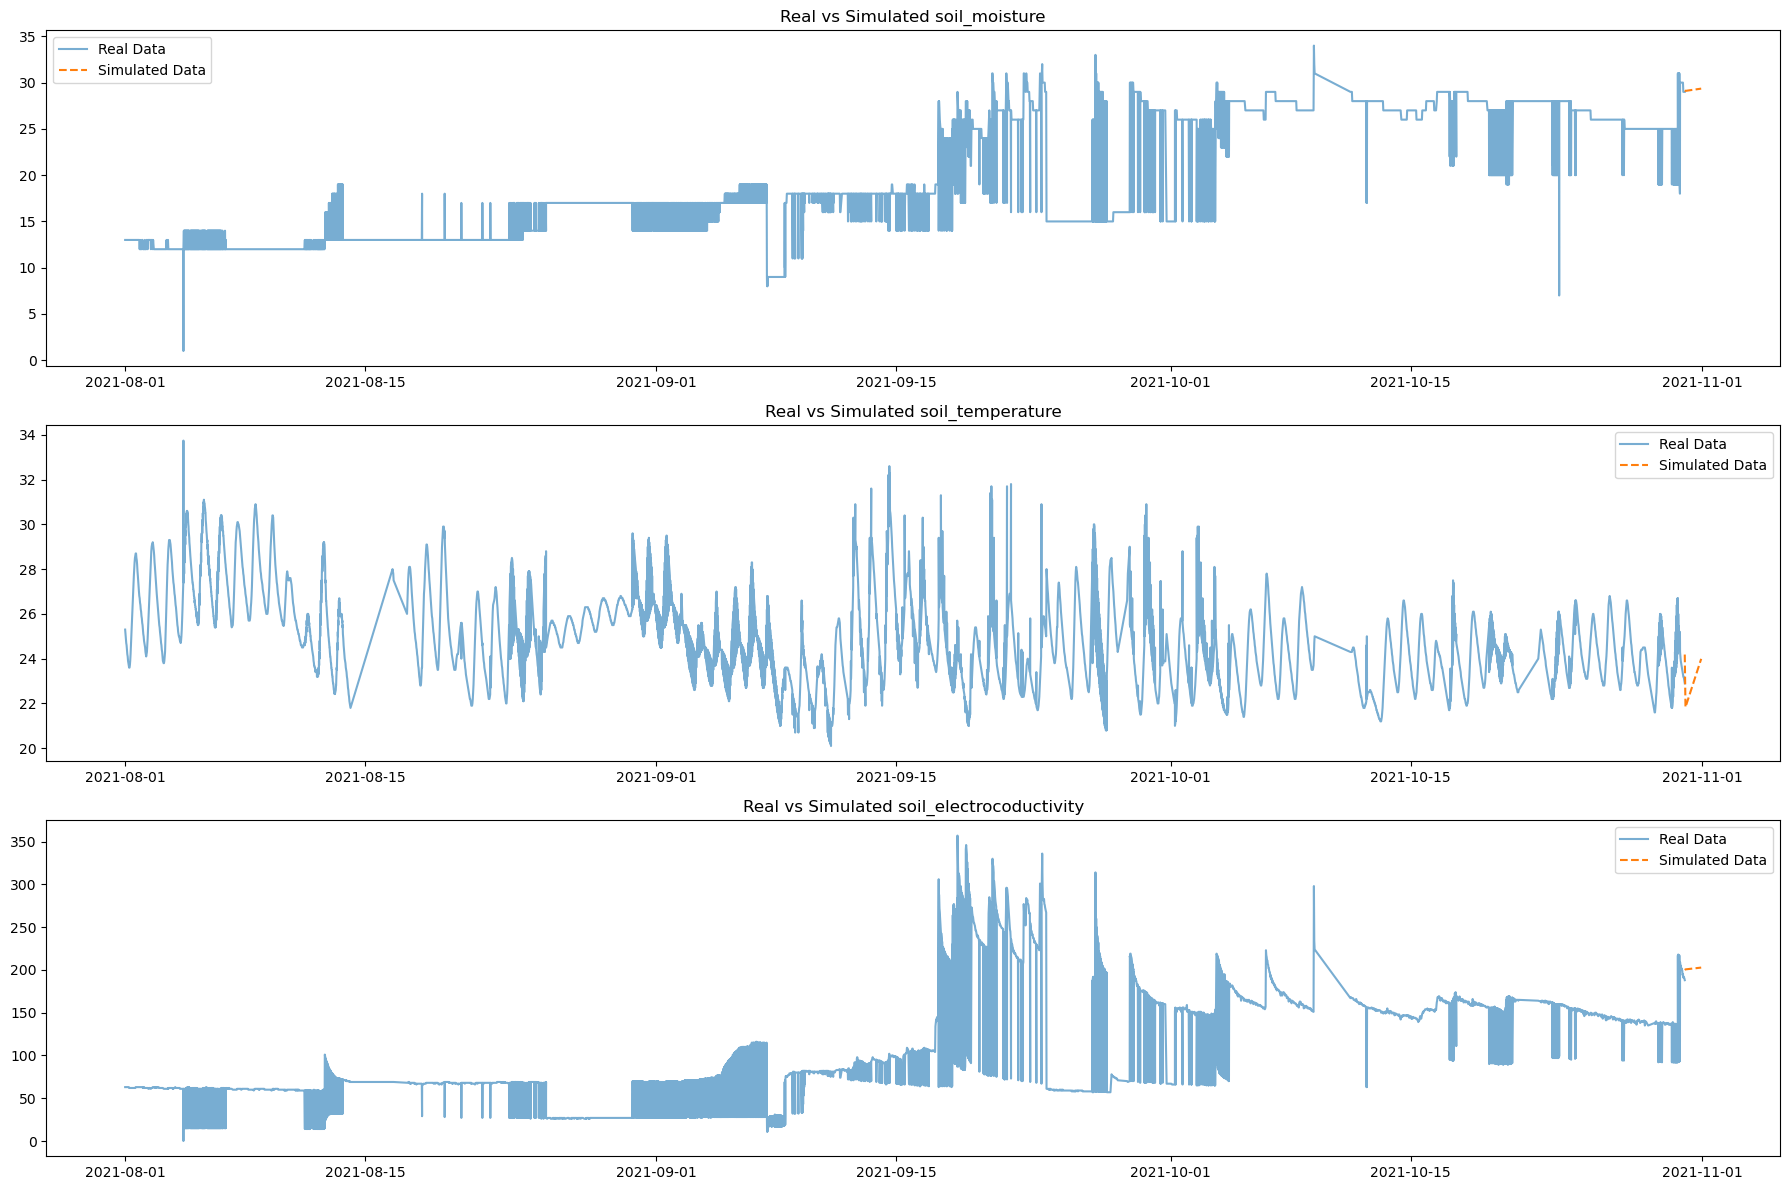

In [58]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from datetime import datetime, timedelta

# Load dataset
df = pd.read_csv("August-October-2021-sectionA1-data.csv")

# Preprocess data
df['createdAt'] = pd.to_datetime(df['createdAt'])
df['hour'] = df['createdAt'].dt.hour
df['day'] = df['createdAt'].dt.day
df['month'] = df['createdAt'].dt.month
df['weekday'] = df['createdAt'].dt.weekday

# Features and target
X = df[['hour', 'day', 'month', 'weekday', 'battery_level']]
y = df[['soil_moisture', 'soil_temperature', 'soil_electrocoductivity']]

# Split dataset
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# Train regression model
model = LinearRegression()
model.fit(X_train, y_train)

# Predictions
y_pred = model.predict(X_test)

# Evaluation metrics
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print("Model Evaluation:")
print(f"MAE: {mae:.2f}")
print(f"MSE: {mse:.2f}")
print(f"R2 Score: {r2:.2f}")

# Generate simulated data for next 24 hours
start_time = df['createdAt'].max()
simulated_timestamps = [start_time + timedelta(hours=i) for i in range(24)]
simulated_features = pd.DataFrame({
    'hour': [ts.hour for ts in simulated_timestamps],
    'day': [ts.day for ts in simulated_timestamps],
    'month': [ts.month for ts in simulated_timestamps],
    'weekday': [ts.weekday() for ts in simulated_timestamps],
    'battery_level': [86] * 24  # Assuming constant battery level
})
simulated_data = model.predict(simulated_features)
simulated_df = pd.DataFrame(simulated_data, columns=['soil_moisture', 'soil_temperature', 'soil_electrocoductivity'])
simulated_df['createdAt'] = simulated_timestamps

# Visualization
plt.figure(figsize=(18, 12))
for i, column in enumerate(['soil_moisture', 'soil_temperature', 'soil_electrocoductivity'], 1):
    plt.subplot(3, 1, i)
    plt.plot(df['createdAt'], df[column], label='Real Data', alpha=0.6)
    plt.plot(simulated_df['createdAt'], simulated_df[column], label='Simulated Data', linestyle='dashed')
    plt.title(f'Real vs Simulated {column}')
    plt.legend()
plt.tight_layout()
plt.show()

# Save simulated data
#simulated_df.to_csv("simulated_sensor_data.csv", index=False)
